In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from cb_sim import (
    BanditEnv, LinearBanditModel, K, ACTION_NAMES, FEATURE_NAMES,
    FEATURE_STATS, W_TRUE, sigmoid, run_bandit, ope_ips_snips,
)

# 1. Contextual Bandits for Re-engagement Notifications

## Scenario

A user has gone silent for $N$ weeks.  We send **one** re-engagement push notification to bring them back.  The system must decide **which message variant** to send, using what it knows about the user.

| Component | Symbol | Description |
|-----------|--------|-------------|
| **Context** | $x$ | Features describing the dormant user (`lifetime_purchases`, `days_as_customer`) |
| **Action** | $a \in \{1,\dots,K\}$ | Which message variant to send ($K=7$) |
| **Reward** | $r \in \{0, 1\}$ | Whether the user clicks through (1) or ignores (0) |

At each round the system observes $x$, chooses $a$, and receives **bandit feedback**: the outcome for the chosen action only.

## Ground-truth click model (unknown to the learner)

$$
p(\text{click} \mid x, a) = \sigma\!\bigl(W_{\text{TRUE}}[a] \cdot x \;+\; \eta\bigr), \quad \eta \sim \mathcal{N}(0,\, \sigma^2_{\text{noise}})
$$

where $x = [1, \;\text{purchases\_std}, \;\text{days\_std}]$ and $\sigma_{\text{noise}} = 1.0$ by default.

The noise term $\eta$ represents **unobserved factors** (mood, timing, device, etc.) that influence click behaviour beyond what the features can capture.  The features are observed perfectly, but they don’t tell the whole story.

> **Jensen’s inequality note:** Because the sigmoid is convex for negative logits (which dominate our environment), adding symmetric noise to the logit *inflates* the observed click rate: $E[\sigma(z + \eta)] > \sigma(z)$ when $z < 0$.  This means baseline CTRs are higher than they would be in a noiseless environment — not because users click more, but because the noise occasionally pushes an unlikely click into the high-probability region of the sigmoid.  The absolute CTR numbers reflect this; what matters is the **relative lift** of a smart policy over random.

The bandit must discover, through exploration and reward feedback, which message works best for which user segment — without ever knowing $W_{\text{TRUE}}$.

> See `theory/` for detailed derivations of decision boundaries, DR estimation, and the role of propensity weighting.

In [2]:
# Initialize the environment and inspect its configuration.
env = BanditEnv(seed=0)

print("Actions:")
for a in range(1, K + 1):
    print(f"  {a}: {ACTION_NAMES[a]}")

print(f"\nFeatures: {FEATURE_NAMES}")
print(f"\nTrue weight matrix W_TRUE (rows=actions, cols=[bias, {', '.join(FEATURE_NAMES)}]):")
for a in range(1, K + 1):
    print(f"  {ACTION_NAMES[a]:30s}  {W_TRUE[a-1]}")

# Sample a few users and show the oracle's best action for each.
x, raw = env.sample_context()
print(f"\nSample user: {raw}")
best = env.oracle_action(x)
for a in range(1, K + 1):
    marker = " ← best" if a == best else ""
    print(f"  {ACTION_NAMES[a]:30s}  p(click) = {env.click_prob(x, a):.3f}{marker}")

for _ in range(5):
    x, raw = env.sample_context()
    best = env.oracle_action(x)
    ctrs = {a: env.click_prob(x, a) for a in range(1, K + 1)}
    print(f"purchases={raw['lifetime_purchases']:2d}  customer_days={raw['days_as_customer']:4d}  "
          f"best → {ACTION_NAMES[best]:34s}  CTRs={[round(ctrs[a], 3) for a in range(1, K+1)]}")

Actions:
  1: See what's new since you left
  2: Your personalized picks await
  3: We miss you! Come back
  4: Trending picks just for you
  5: Flash deal: 24h only
  6: Your friends are shopping
  7: We saved your favorites

Features: ['lifetime_purchases', 'days_as_customer']

True weight matrix W_TRUE (rows=actions, cols=[bias, lifetime_purchases, days_as_customer]):
  See what's new since you left   [-2.5  0.4 -0.7]
  Your personalized picks await   [-2.5  0.7  0.4]
  We miss you! Come back          [-2.8 -0.4  1. ]
  Trending picks just for you     [-2.2 -0.2 -0.4]
  Flash deal: 24h only            [-3.5  1.2 -0.8]
  Your friends are shopping       [-3.8 -0.4  1.5]
  We saved your favorites         [-2.4   0.15  0.15]

Sample user: {'lifetime_purchases': 2, 'days_as_customer': 30}
  See what's new since you left   p(click) = 0.094
  Your personalized picks await   p(click) = 0.067
  We miss you! Come back          p(click) = 0.042
  Trending picks just for you     p(click) = 0.11

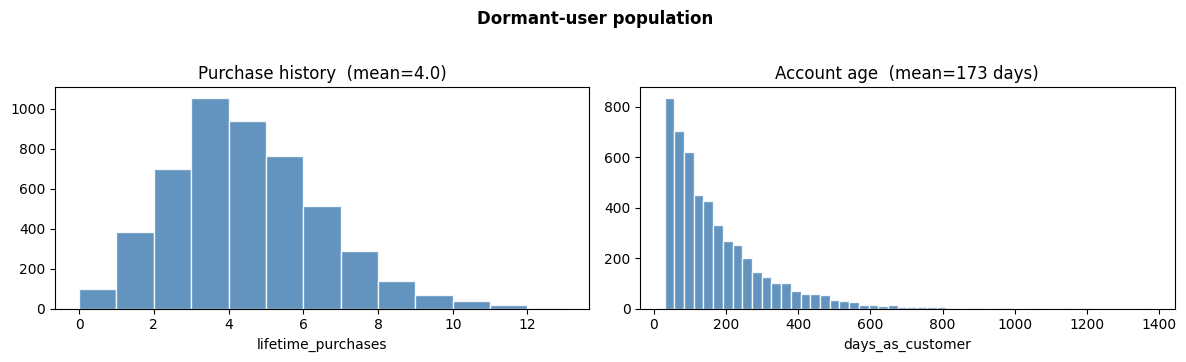

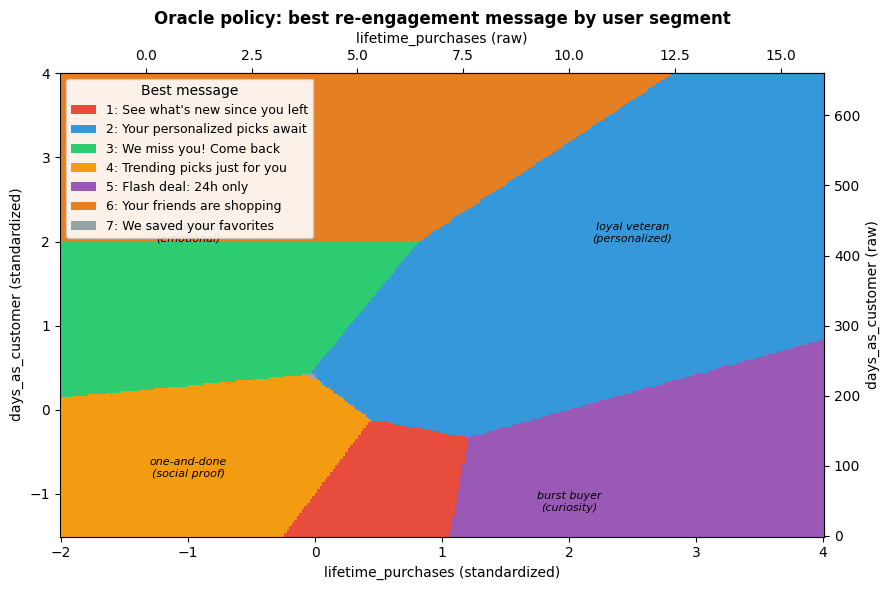

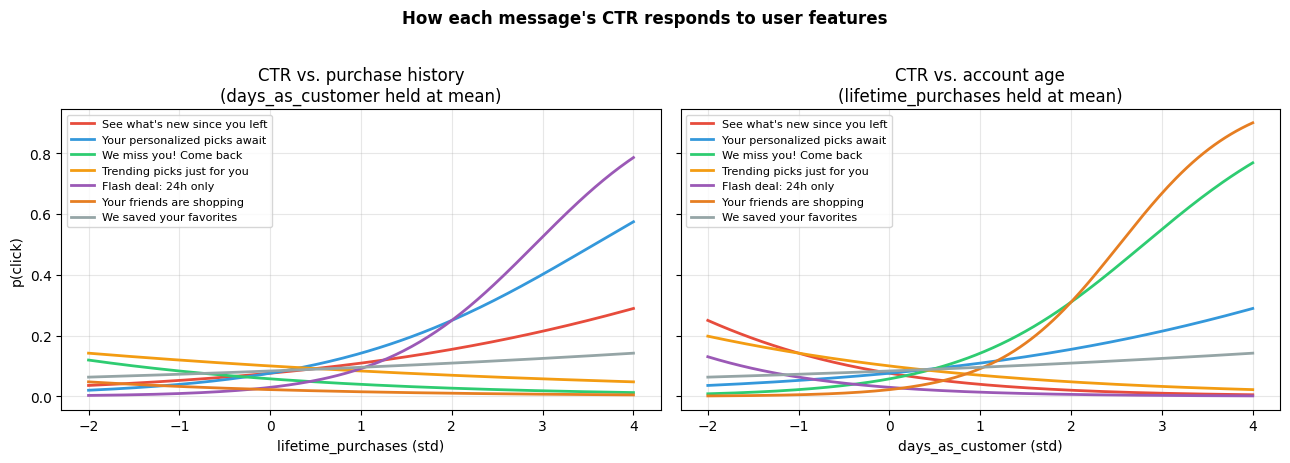

In [3]:
ACTION_COLORS = [
    "#e74c3c", "#3498db", "#2ecc71", "#f39c12",  # original 4
    "#9b59b6", "#e67e22", "#95a5a6",              # urgency, peer pressure, nostalgia
]

# ── 1. Feature distributions ─────────────────────────────────────────────────
N_viz = 5000
env_viz = BanditEnv(seed=123)
samples = [env_viz.sample_context() for _ in range(N_viz)]
raw_purchases = [s[1]["lifetime_purchases"] for s in samples]
raw_days      = [s[1]["days_as_customer"]   for s in samples]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.hist(raw_purchases, bins=range(0, max(raw_purchases) + 2),
         edgecolor="white", alpha=0.85, color="steelblue")
ax1.set_xlabel("lifetime_purchases")
ax1.set_title(f"Purchase history  (mean={np.mean(raw_purchases):.1f})")

ax2.hist(raw_days, bins=50, edgecolor="white", alpha=0.85, color="steelblue")
ax2.set_xlabel("days_as_customer")
ax2.set_title(f"Account age  (mean={np.mean(raw_days):.0f} days)")

fig.suptitle("Dormant-user population", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Oracle best-action heatmap ────────────────────────────────────────────
ps_grid = np.linspace(-2, 4, 300)
ds_grid = np.linspace(-1.5, 4, 300)
P, D = np.meshgrid(ps_grid, ds_grid)

best = np.zeros_like(P, dtype=int)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        x = np.array([1.0, P[i, j], D[i, j]])
        best[i, j] = env.oracle_action(x)

cmap = ListedColormap(ACTION_COLORS)

fig, ax = plt.subplots(figsize=(9, 6))
ax.pcolormesh(ps_grid, ds_grid, best, cmap=cmap, vmin=0.5, vmax=K + 0.5, shading="auto")

legend_elements = [
    Patch(facecolor=ACTION_COLORS[a - 1], label=f"{a}: {ACTION_NAMES[a]}")
    for a in range(1, K + 1)
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9,
          framealpha=0.9, title="Best message")

# Segment annotations
ax.text( 2.0, -1.2, "burst buyer\n(curiosity)", ha="center", fontsize=8, style="italic")
ax.text( 2.5,  2.0, "loyal veteran\n(personalized)", ha="center", fontsize=8, style="italic")
ax.text(-1.0,  2.0, "long-time browser\n(emotional)", ha="center", fontsize=8, style="italic")
ax.text(-1.0, -0.8, "one-and-done\n(social proof)", ha="center", fontsize=8, style="italic")
ax.text( 3.5, -1.2, "extreme impulse\n(urgency)", ha="center", fontsize=8, style="italic", color="#9b59b6")
ax.text(-1.5,  3.5, "extreme browser\n(peer pressure)", ha="center", fontsize=8, style="italic", color="#e67e22")

# Raw-value secondary axes
ax_top = ax.secondary_xaxis("top",
    functions=(lambda s: s * 3 + 4, lambda r: (r - 4) / 3))
ax_top.set_xlabel("lifetime_purchases (raw)")
ax_right = ax.secondary_yaxis("right",
    functions=(lambda s: s * 120 + 180, lambda r: (r - 180) / 120))
ax_right.set_ylabel("days_as_customer (raw)")

ax.set_xlabel("lifetime_purchases (standardized)")
ax.set_ylabel("days_as_customer (standardized)")
ax.set_title("Oracle policy: best re-engagement message by user segment", fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3. CTR profiles ──────────────────────────────────────────────────────────
# Sweep each feature while holding the other at its population mean (std=0).
sweep = np.linspace(-2, 4, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for a in range(1, K + 1):
    ctrs = [sigmoid(W_TRUE[a-1] @ np.array([1.0, s, 0.0])) for s in sweep]
    ax1.plot(sweep, ctrs, label=ACTION_NAMES[a], color=ACTION_COLORS[a-1], lw=2)
ax1.set_xlabel("lifetime_purchases (std)")
ax1.set_ylabel("p(click)")
ax1.set_title("CTR vs. purchase history\n(days_as_customer held at mean)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

for a in range(1, K + 1):
    ctrs = [sigmoid(W_TRUE[a-1] @ np.array([1.0, 0.0, s])) for s in sweep]
    ax2.plot(sweep, ctrs, label=ACTION_NAMES[a], color=ACTION_COLORS[a-1], lw=2)
ax2.set_xlabel("days_as_customer (std)")
ax2.set_title("CTR vs. account age\n(lifetime_purchases held at mean)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle("How each message's CTR responds to user features", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. Custom Linear Bandit Model

Our learner is a `LinearBanditModel` — $K$ independent online logistic regressions, one per action.  It doesn't know $W_{\text{TRUE}}$ and must figure out which message works best through trial and error.

**Model:** Each action $a$ has its own weight vector $\hat{w}_a$.  The predicted click probability is $\hat{p}(x, a) = \sigma(\hat{w}_a \cdot x)$, updated via SGD on log-loss after each observation.

**Policy:** $\varepsilon$-greedy — with probability $\varepsilon$ explore uniformly, otherwise pick the action with the highest predicted CTR.

**Update methods** (three variants to compare):

| Method | Update rule | Tradeoff |
|--------|------------|----------|
| **Direct** | SGD on chosen action only | Simple, low variance; biased under non-uniform exploration |
| **IPS** | Gradient weighted by $1/\mu(a \mid x)$ | Unbiased; higher variance when propensity is small |
| **DR** | IPS-corrected chosen action; model prediction for unchosen | Best of both — but with a single model, reduces to IPS (see `theory/cb_dr_derivation.md`) |

> See `theory/` for detailed derivations of epsilon-greedy, propensity weighting, IPS/SNIPS, and Doubly Robust estimation.

### Pipeline overview

```
 Phase 1: Warm-up          Phase 2: OPE              Phase 3: Live
┌───────────────────┐    ┌────────────────────┐    ┌──────────────────┐
│  ε = 1 (uniform)  │    │  Logged data from  │    │  ε = best (OPE)  │
│                   │    │  Phase 1           │    │                  │
│  Collect data +   │───>│                    │───>│  Exploit + learn │
│  Train model      │    │  IPS / SNIPS eval  │    │  online          │
│  Save logs        │    │  Pick best ε       │    │                  │
└───────────────────┘    └────────────────────┘    └──────────────────┘
     ~9% CTR                (offline, no new            ~12%+ CTR
   (random baseline)          data needed)           (learned policy)
```

1. **Warm-up** ($\varepsilon=1$): uniform exploration collects unbiased logs + trains the model online
2. **OPE**: use IPS/SNIPS on logged data to pick the best $\varepsilon$ without deploying anything
3. **Live**: deploy with the chosen $\varepsilon$, keep learning online


In [4]:
EPSILON = 0.50

# Initialize the environment and inspect its configuration.
env = BanditEnv(seed=0)

# Create the custom bandit model and demonstrate a single prediction.
model = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)

# sample context
x, raw = env.sample_context()
print("Untrained model, all w=0")
print("predict_proba(x):", model.predict_proba(x))

# Best will always be first action
print("action_probs(x, epsilon=0.10):", model.action_probs(x, epsilon=EPSILON))

# sample action
action, prop = model.sample_action(x, epsilon=EPSILON, rng=env.rng)
print("sample_action(x, epsilon=0.10):", action, prop)


Untrained model, all w=0
predict_proba(x): [0.5 0.5 0.5 0.5 0.5 0.5 0.5]
action_probs(x, epsilon=0.10): [0.57142857 0.07142857 0.07142857 0.07142857 0.07142857 0.07142857
 0.07142857]
sample_action(x, epsilon=0.10): 5 0.07142857142857142


In [5]:
# Initialize the environment and inspect its configuration.
env = BanditEnv(seed=0)

# Create the custom bandit model and demonstrate a single prediction.
model = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)

x, raw = env.sample_context()
p_hat = model.predict_proba(x)
probs = model.action_probs(x, epsilon=1.0)

print(f"user: {raw}")
print(f"x = {np.round(x, 3)}")
print(f"predicted P(click) per action: {np.round(p_hat, 4)}  (all 0.5 — untrained model)")
print(f"action probs (ε=1): {np.round(probs, 3)}  (uniform)")
print()

action, prop = model.sample_action(x, epsilon=1.0, rng=env.rng)
print(f"sampled → action {action} ({ACTION_NAMES[action]}), propensity={prop:.3f}")
print() 

user: {'lifetime_purchases': 2, 'days_as_customer': 30}
x = [ 1.     0.    -0.331]
predicted P(click) per action: [0.5 0.5 0.5 0.5 0.5 0.5 0.5]  (all 0.5 — untrained model)
action probs (ε=1): [0.143 0.143 0.143 0.143 0.143 0.143 0.143]  (uniform)

sampled → action 6 (Your friends are shopping), propensity=0.143



In [6]:
# One full interaction step — the core CB loop.
x, raw = env.sample_context()

# 1) Epsilon-greedy: get action distribution, sample
action, prop = model.sample_action(x, epsilon=1.0, rng=env.rng)

# 2) Environment reveals click/no-click for chosen action only
click = env.sample_click(x, action)

# 3) Update the model's weights for this action
model.update(x, action, click, prop, method='direct')

print(f"user: {raw}")
print(f"sent: {ACTION_NAMES[action]}  (propensity={prop:.3f})")
print(f"clicked: {bool(click)}  (true p(click)={env.click_prob(x, action):.3f})")
print(f"W_hat after update:")
for a in range(1, K + 1):
    print(f"  {ACTION_NAMES[a]:30s}  {np.round(model.W[a-1], 4)}")



user: {'lifetime_purchases': 6, 'days_as_customer': 370}
sent: See what's new since you left  (propensity=0.143)
clicked: False  (true p(click)=0.037)
W_hat after update:
  See what's new since you left   [-0.05   -0.04   -0.0779]
  Your personalized picks await   [0. 0. 0.]
  We miss you! Come back          [0. 0. 0.]
  Trending picks just for you     [0. 0. 0.]
  Flash deal: 24h only            [0. 0. 0.]
  Your friends are shopping       [0. 0. 0.]
  We saved your favorites         [0. 0. 0.]


In [7]:
# Phase 1: Warm-up (ε=1, uniform exploration).
# The model learns from scratch; every action gets equal probability.
# Weights get updates, but since (1-ε) = 0, all actions are selected equally.

# Initialize the environment and inspect its configuration.
env = BanditEnv(seed=0)


model_warm = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)
env_log = BanditEnv(seed=42)

ctr_warm, logs = run_bandit(model_warm, env_log, N=5000, epsilon=1.0,
                            method='direct', report_every=1000, log=True)

print(f"\nmean logged propensity: {np.mean(logs['props']):.3f}")
print(f"unique actions: {np.unique(logs['actions'])}")
print(f"warm-up CTR: {np.mean(logs['clicks']):.4f}")

print(f"\nLearned W_hat after warm-up:")
for a in range(1, K + 1):
    print(f"  {ACTION_NAMES[a]:30s}  {np.round(model_warm.W[a-1], 3)}")
print(f"\nTrue W_TRUE for comparison:")
for a in range(1, K + 1):
    print(f"  {ACTION_NAMES[a]:30s}  {W_TRUE[a-1]}")


t= 1000  overall_CTR=0.117  recent_CTR=0.117  probs=[0.143 0.143 0.143 0.143 0.143 0.143 0.143]
t= 2000  overall_CTR=0.115  recent_CTR=0.112  probs=[0.143 0.143 0.143 0.143 0.143 0.143 0.143]
t= 3000  overall_CTR=0.113  recent_CTR=0.109  probs=[0.143 0.143 0.143 0.143 0.143 0.143 0.143]
t= 4000  overall_CTR=0.110  recent_CTR=0.100  probs=[0.143 0.143 0.143 0.143 0.143 0.143 0.143]
t= 5000  overall_CTR=0.108  recent_CTR=0.104  probs=[0.143 0.143 0.143 0.143 0.143 0.143 0.143]

mean logged propensity: 0.143
unique actions: [1 2 3 4 5 6 7]
warm-up CTR: 0.1084

Learned W_hat after warm-up:
  See what's new since you left   [-2.295 -0.108 -1.018]
  Your personalized picks await   [-2.14   0.269 -0.106]
  We miss you! Come back          [-2.112 -0.484  1.013]
  Trending picks just for you     [-1.565 -0.112 -0.421]
  Flash deal: 24h only            [-2.714 -0.032 -0.884]
  Your friends are shopping       [-3.182 -0.871  1.215]
  We saved your favorites         [-1.665 -0.257 -0.215]

True W_

In [8]:
# Phase 2: Off-Policy Evaluation — pick the best epsilon.
eps_candidates = [0.01, 0.05, 0.1, 0.2, 0.5]
results = []

for eps in eps_candidates:
    ips, snips = ope_ips_snips(model_warm, logs, epsilon=eps, mu=0.25)
    results.append((eps, ips, snips))

results_sorted = sorted(results, key=lambda t: t[2], reverse=True)
for eps, ips, snips in results_sorted:
    print(f"ε={eps:>4}  IPS={ips:.4f}  SNIPS={snips:.4f}")

best_eps = results_sorted[0][0]
print(f"\nbest epsilon by SNIPS: {best_eps}")


ε=0.01  IPS=0.0893  SNIPS=0.1618
ε=0.05  IPS=0.0882  SNIPS=0.1595
ε= 0.1  IPS=0.0868  SNIPS=0.1568
ε= 0.2  IPS=0.0841  SNIPS=0.1512
ε= 0.5  IPS=0.0758  SNIPS=0.1349

best epsilon by SNIPS: 0.01


In [9]:
# Phase 3: Deploy the OPE-selected policy, keep learning online.
model_live = model_warm.copy()
env_live = BanditEnv(seed=99)

ctr_live = run_bandit(model_live, env_live, N=5000, epsilon=best_eps,
                      method='direct', report_every=500)

oracle_ctr = env.oracle_ctr()
print(f"\nResults:")
print(f"  warm-up CTR (ε=1, random):  {ctr_warm:.4f}")
print(f"  live CTR (ε={best_eps}):       {ctr_live:.4f}")
print(f"  oracle CTR (upper bound):   {oracle_ctr:.4f}")


t=  500  overall_CTR=0.188  recent_CTR=0.188  probs=[0.001 0.991 0.001 0.001 0.001 0.001 0.001]
t= 1000  overall_CTR=0.179  recent_CTR=0.170  probs=[0.001 0.001 0.001 0.991 0.001 0.001 0.001]
t= 1500  overall_CTR=0.175  recent_CTR=0.166  probs=[0.001 0.991 0.001 0.001 0.001 0.001 0.001]
t= 2000  overall_CTR=0.182  recent_CTR=0.204  probs=[0.001 0.001 0.001 0.991 0.001 0.001 0.001]
t= 2500  overall_CTR=0.180  recent_CTR=0.174  probs=[0.001 0.991 0.001 0.001 0.001 0.001 0.001]
t= 3000  overall_CTR=0.178  recent_CTR=0.166  probs=[0.001 0.991 0.001 0.001 0.001 0.001 0.001]
t= 3500  overall_CTR=0.180  recent_CTR=0.194  probs=[0.001 0.991 0.001 0.001 0.001 0.001 0.001]
t= 4000  overall_CTR=0.178  recent_CTR=0.162  probs=[0.991 0.001 0.001 0.001 0.001 0.001 0.001]
t= 4500  overall_CTR=0.176  recent_CTR=0.160  probs=[0.991 0.001 0.001 0.001 0.001 0.001 0.001]
t= 5000  overall_CTR=0.177  recent_CTR=0.182  probs=[0.001 0.991 0.001 0.001 0.001 0.001 0.001]

Results:
  warm-up CTR (ε=1, random):  

## 3. Exploration schedule comparison

How much should we explore?  Instead of OPE (which is better suited for comparing *different models*), we can answer this directly by running the bandit under several $\varepsilon$ strategies and comparing CTR over time.

The environment uses the default logit noise ($\sigma_{\text{noise}} = 1.0$), so reward signals are noisy and the learning problem is non-trivial.

**Strategies:**
- **Fixed $\varepsilon$** at various levels — shows the tradeoff: high $\varepsilon$ explores too much, low $\varepsilon$ exploits a possibly-wrong model
- **Decay schedule** $\varepsilon(t) = \max(0.01,\; 1.0 \cdot 0.9995^t)$ — starts at pure exploration and gradually shifts to exploitation
- **Warm-up → exploit** — 1,000 rounds at $\varepsilon=1$, then switch to $\varepsilon=0.01$

oracle CTR = 0.1895
--------------------------------------------------
  ε=1.0 (uniform)            final CTR=0.1106
  ε=0.3                      final CTR=0.1509
  ε=0.1                      final CTR=0.1635
  ε=0.01 (near-greedy)       final CTR=0.1680
  decay (1→0.01)             final CTR=0.1611
  warm-up→exploit            final CTR=0.1677


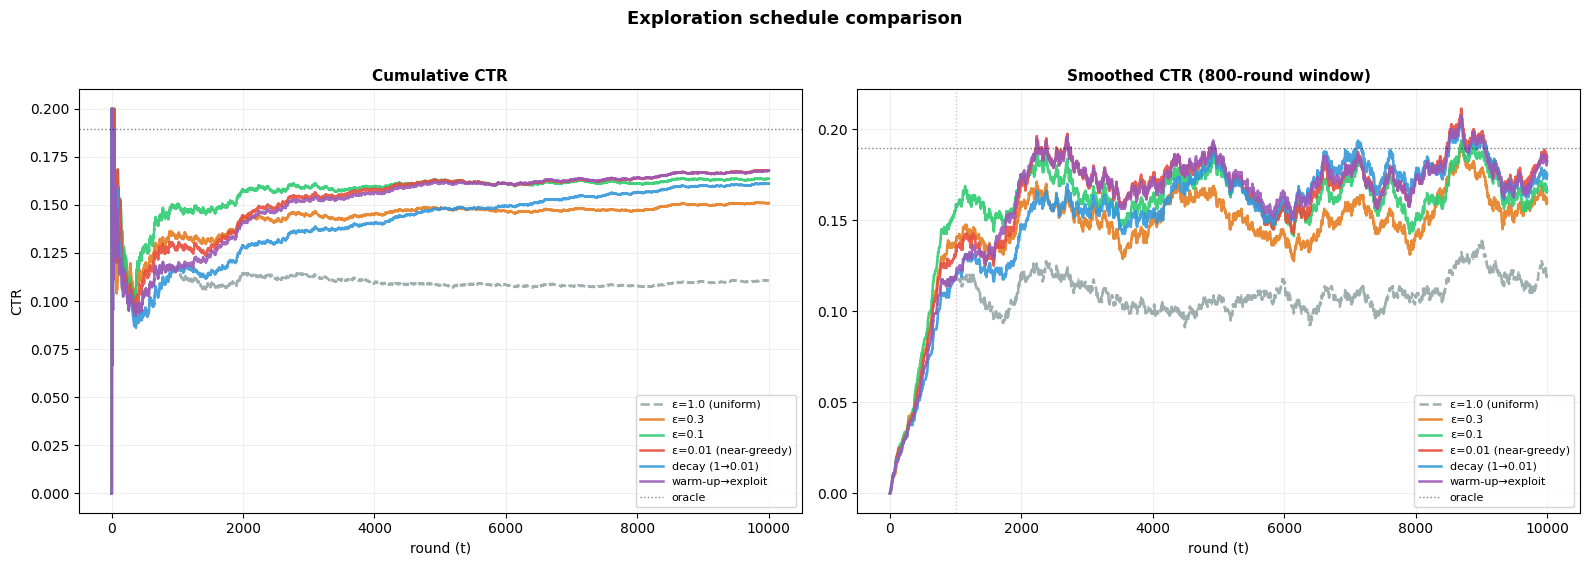

In [10]:
def run_with_tracking(env_seed, N, epsilon_fn, method='direct', lr=0.1):
    model = LinearBanditModel(n_actions=K, n_features=3, lr=lr)
    env = BanditEnv(seed=env_seed)
    clicks = 0
    cumulative_ctr = np.zeros(N)
    raw_clicks = np.zeros(N, dtype=np.float64)
    for t in range(N):
        eps = epsilon_fn if isinstance(epsilon_fn, (int, float)) else epsilon_fn(t)
        x, _ = env.sample_context()
        action, prop = model.sample_action(x, eps, env.rng)
        click = env.sample_click(x, action)
        model.update(x, action, click, prop, method=method)
        clicks += click
        cumulative_ctr[t] = clicks / (t + 1)
        raw_clicks[t] = click
    return cumulative_ctr, raw_clicks, model


def smooth(y, window=500):
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='full')[:len(y)]


N_TOTAL = 10_000
SEED = 42
N_WARMUP_SCHED = 1000
SMOOTH_WINDOW = 800

strategies = {
    'ε=1.0 (uniform)':      (1.0,   '#95a5a6', '--'),
    'ε=0.3':                (0.3,   '#e67e22', '-'),
    'ε=0.1':                (0.1,   '#2ecc71', '-'),
    'ε=0.01 (near-greedy)': (0.01,  '#e74c3c', '-'),
    'decay (1→0.01)':       (lambda t: max(0.01, 1.0 * 0.9995**t), '#3498db', '-'),
    'warm-up→exploit':      (lambda t: 1.0 if t < N_WARMUP_SCHED else 0.01,
                             '#9b59b6', '-'),
}

oracle_ctr = BanditEnv(seed=0).oracle_ctr(N=20000)
print(f'oracle CTR = {oracle_ctr:.4f}')
print('-' * 50)

fig, (ax_cum, ax_smooth) = plt.subplots(1, 2, figsize=(16, 5.5))
ts = np.arange(1, N_TOTAL + 1)

for name, (eps_fn, color, ls) in strategies.items():
    cum, raw, mdl = run_with_tracking(SEED, N_TOTAL, eps_fn)
    ax_cum.plot(ts, cum, label=name, color=color, ls=ls, lw=1.8, alpha=0.9)
    ax_smooth.plot(ts, smooth(raw, SMOOTH_WINDOW), label=name, color=color,
                   ls=ls, lw=1.8, alpha=0.9)
    print(f'  {name:25s}  final CTR={cum[-1]:.4f}')

for ax in (ax_cum, ax_smooth):
    ax.axhline(oracle_ctr, color='black', ls=':', lw=1, alpha=0.5, label='oracle')
    ax.set_xlabel('round (t)')
    ax.grid(alpha=0.2)

ax_cum.set_ylabel('CTR')
ax_cum.set_title('Cumulative CTR', fontweight='bold', fontsize=11)
ax_cum.legend(fontsize=8, loc='lower right')

ax_smooth.set_title(f'Smoothed CTR ({SMOOTH_WINDOW}-round window)',
                    fontweight='bold', fontsize=11)
ax_smooth.legend(fontsize=8, loc='lower right')
ax_smooth.axvline(N_WARMUP_SCHED, color='#9b59b6', ls=':', alpha=0.4, lw=1)

fig.suptitle('Exploration schedule comparison',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


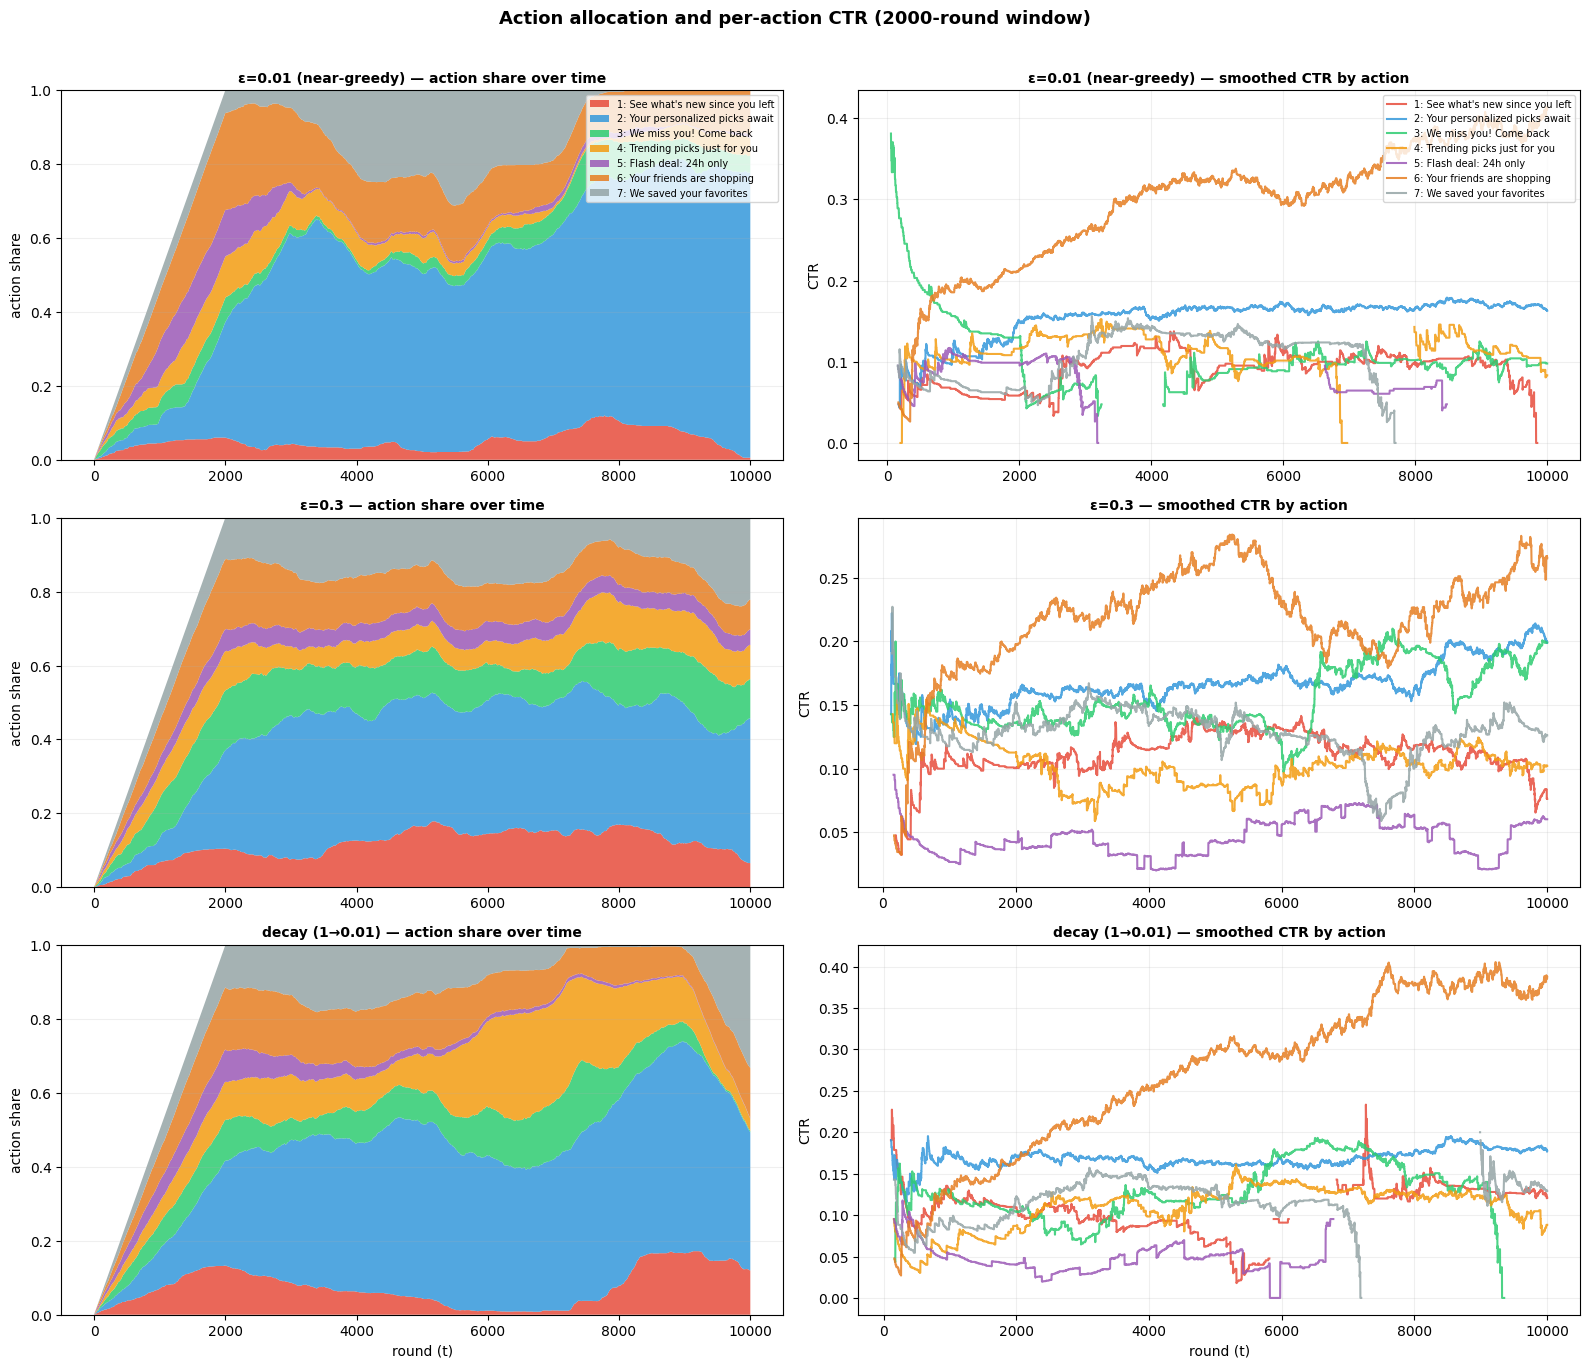

In [11]:
# Per-action deep dive: action share + per-action CTR for 3 strategies.

def run_with_action_tracking(env_seed, N, epsilon_fn, lr=0.1):
    model = LinearBanditModel(n_actions=K, n_features=3, lr=lr)
    env = BanditEnv(seed=env_seed)
    actions_log = np.zeros(N, dtype=np.int32)
    clicks_log = np.zeros(N, dtype=np.int32)
    for t in range(N):
        eps = epsilon_fn if isinstance(epsilon_fn, (int, float)) else epsilon_fn(t)
        x, _ = env.sample_context()
        action, prop = model.sample_action(x, eps, env.rng)
        click = env.sample_click(x, action)
        model.update(x, action, click, prop, method='direct')
        actions_log[t] = action
        clicks_log[t] = click
    return actions_log, clicks_log


def smoothed_action_share(actions_log, window=500):
    """Smoothed fraction of traffic to each action over time."""
    N = len(actions_log)
    shares = np.zeros((K, N))
    kernel = np.ones(window) / window
    for a in range(1, K + 1):
        indicator = (actions_log == a).astype(float)
        shares[a - 1] = np.convolve(indicator, kernel, mode='full')[:N]
    return shares


def smoothed_ctr_by_action(actions_log, clicks_log, window=500):
    """Smoothed CTR for each action (NaN where action not served enough)."""
    N = len(actions_log)
    kernel = np.ones(window) / window
    ctrs = np.full((K, N), np.nan)
    for a in range(1, K + 1):
        mask = (actions_log == a).astype(float)
        served = np.convolve(mask, kernel, mode='full')[:N]
        clicks = np.convolve((mask * clicks_log), kernel, mode='full')[:N]
        valid = served > 0.01
        ctrs[a - 1, valid] = clicks[valid] / served[valid]
    return ctrs


WINDOW = 2000
focus_strategies = [
    ('ε=0.01 (near-greedy)', 0.01),
    ('ε=0.3',                0.3),
    ('decay (1→0.01)',       lambda t: max(0.01, 1.0 * 0.9995**t)),
]

fig, axes = plt.subplots(len(focus_strategies), 2, figsize=(16, 4.5 * len(focus_strategies)))
ts = np.arange(1, N_TOTAL + 1)

for row, (name, eps_fn) in enumerate(focus_strategies):
    actions_log, clicks_log = run_with_action_tracking(SEED, N_TOTAL, eps_fn)
    shares = smoothed_action_share(actions_log, window=WINDOW)
    ctrs = smoothed_ctr_by_action(actions_log, clicks_log, window=WINDOW)

    ax_share, ax_ctr = axes[row]

    ax_share.stackplot(ts, shares, labels=[f'{a}: {ACTION_NAMES[a]}' for a in range(1, K+1)],
                       colors=ACTION_COLORS, alpha=0.85)
    ax_share.set_ylim(0, 1)
    ax_share.set_ylabel('action share')
    ax_share.set_title(f'{name} — action share over time', fontweight='bold', fontsize=10)
    if row == 0:
        ax_share.legend(fontsize=7, loc='upper right')
    ax_share.grid(axis='y', alpha=0.2)

    for a in range(1, K + 1):
        ax_ctr.plot(ts, ctrs[a - 1], color=ACTION_COLORS[a - 1],
                    label=f'{a}: {ACTION_NAMES[a]}', lw=1.5, alpha=0.85)
    ax_ctr.set_ylabel('CTR')
    ax_ctr.set_title(f'{name} — smoothed CTR by action', fontweight='bold', fontsize=10)
    if row == 0:
        ax_ctr.legend(fontsize=7, loc='upper right')
    ax_ctr.grid(alpha=0.2)

    for ax in (ax_share, ax_ctr):
        if row == len(focus_strategies) - 1:
            ax.set_xlabel('round (t)')

fig.suptitle(f'Action allocation and per-action CTR ({WINDOW}-round window)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 4. Evolving decision boundaries

How does exploration rate affect learning?  Each row below uses a different $\varepsilon$; each column is a time checkpoint.  The percentage shows agreement with the oracle policy.

**Key observations:**

- **Low $\varepsilon$ overfits then degrades.** With $\varepsilon=0.01$, agreement peaks then *drops*.  The model exploits one action per region, so only that action's weights receive (noisy) gradient updates.  With $K=7$ actions (including niche variants the model barely tries), many weight vectors go stale.

- **High $\varepsilon$ never stabilises.**  At $\varepsilon=1.0$, all seven actions' weights are continuously pushed by noisy gradients.  Great for estimation balance, but the decision boundaries jitter because SGD with a fixed learning rate doesn't converge in a noisy setting.

- **Moderate $\varepsilon$ wins on policy quality.**  $\varepsilon=0.3$ reaches the highest final agreement (~72%) because it balances *data diversity* (all actions get regular updates) with *exploitation stability* (the greedy action dominates enough that boundaries don't wander).

- **Same data volume, different data distribution.**  All strategies see 10k rounds, but the *composition* differs.  Low $\varepsilon$ concentrates data on the greedy action — if the initial belief is wrong (due to noise), the model rarely tries alternatives and can't self-correct.  This is the fundamental **information asymmetry** of bandit feedback.

- **Noise amplifies all of this.**  The unobserved-factor noise ($\sigma=1.0$) inflates gradient variance.  In a noiseless environment, even aggressive exploitation would converge, because the gradient signal is clean.  With noise, learning rate decay or a more adaptive optimiser would help — but for this demonstration, the fixed-lr SGD makes the exploration tradeoff visually striking.

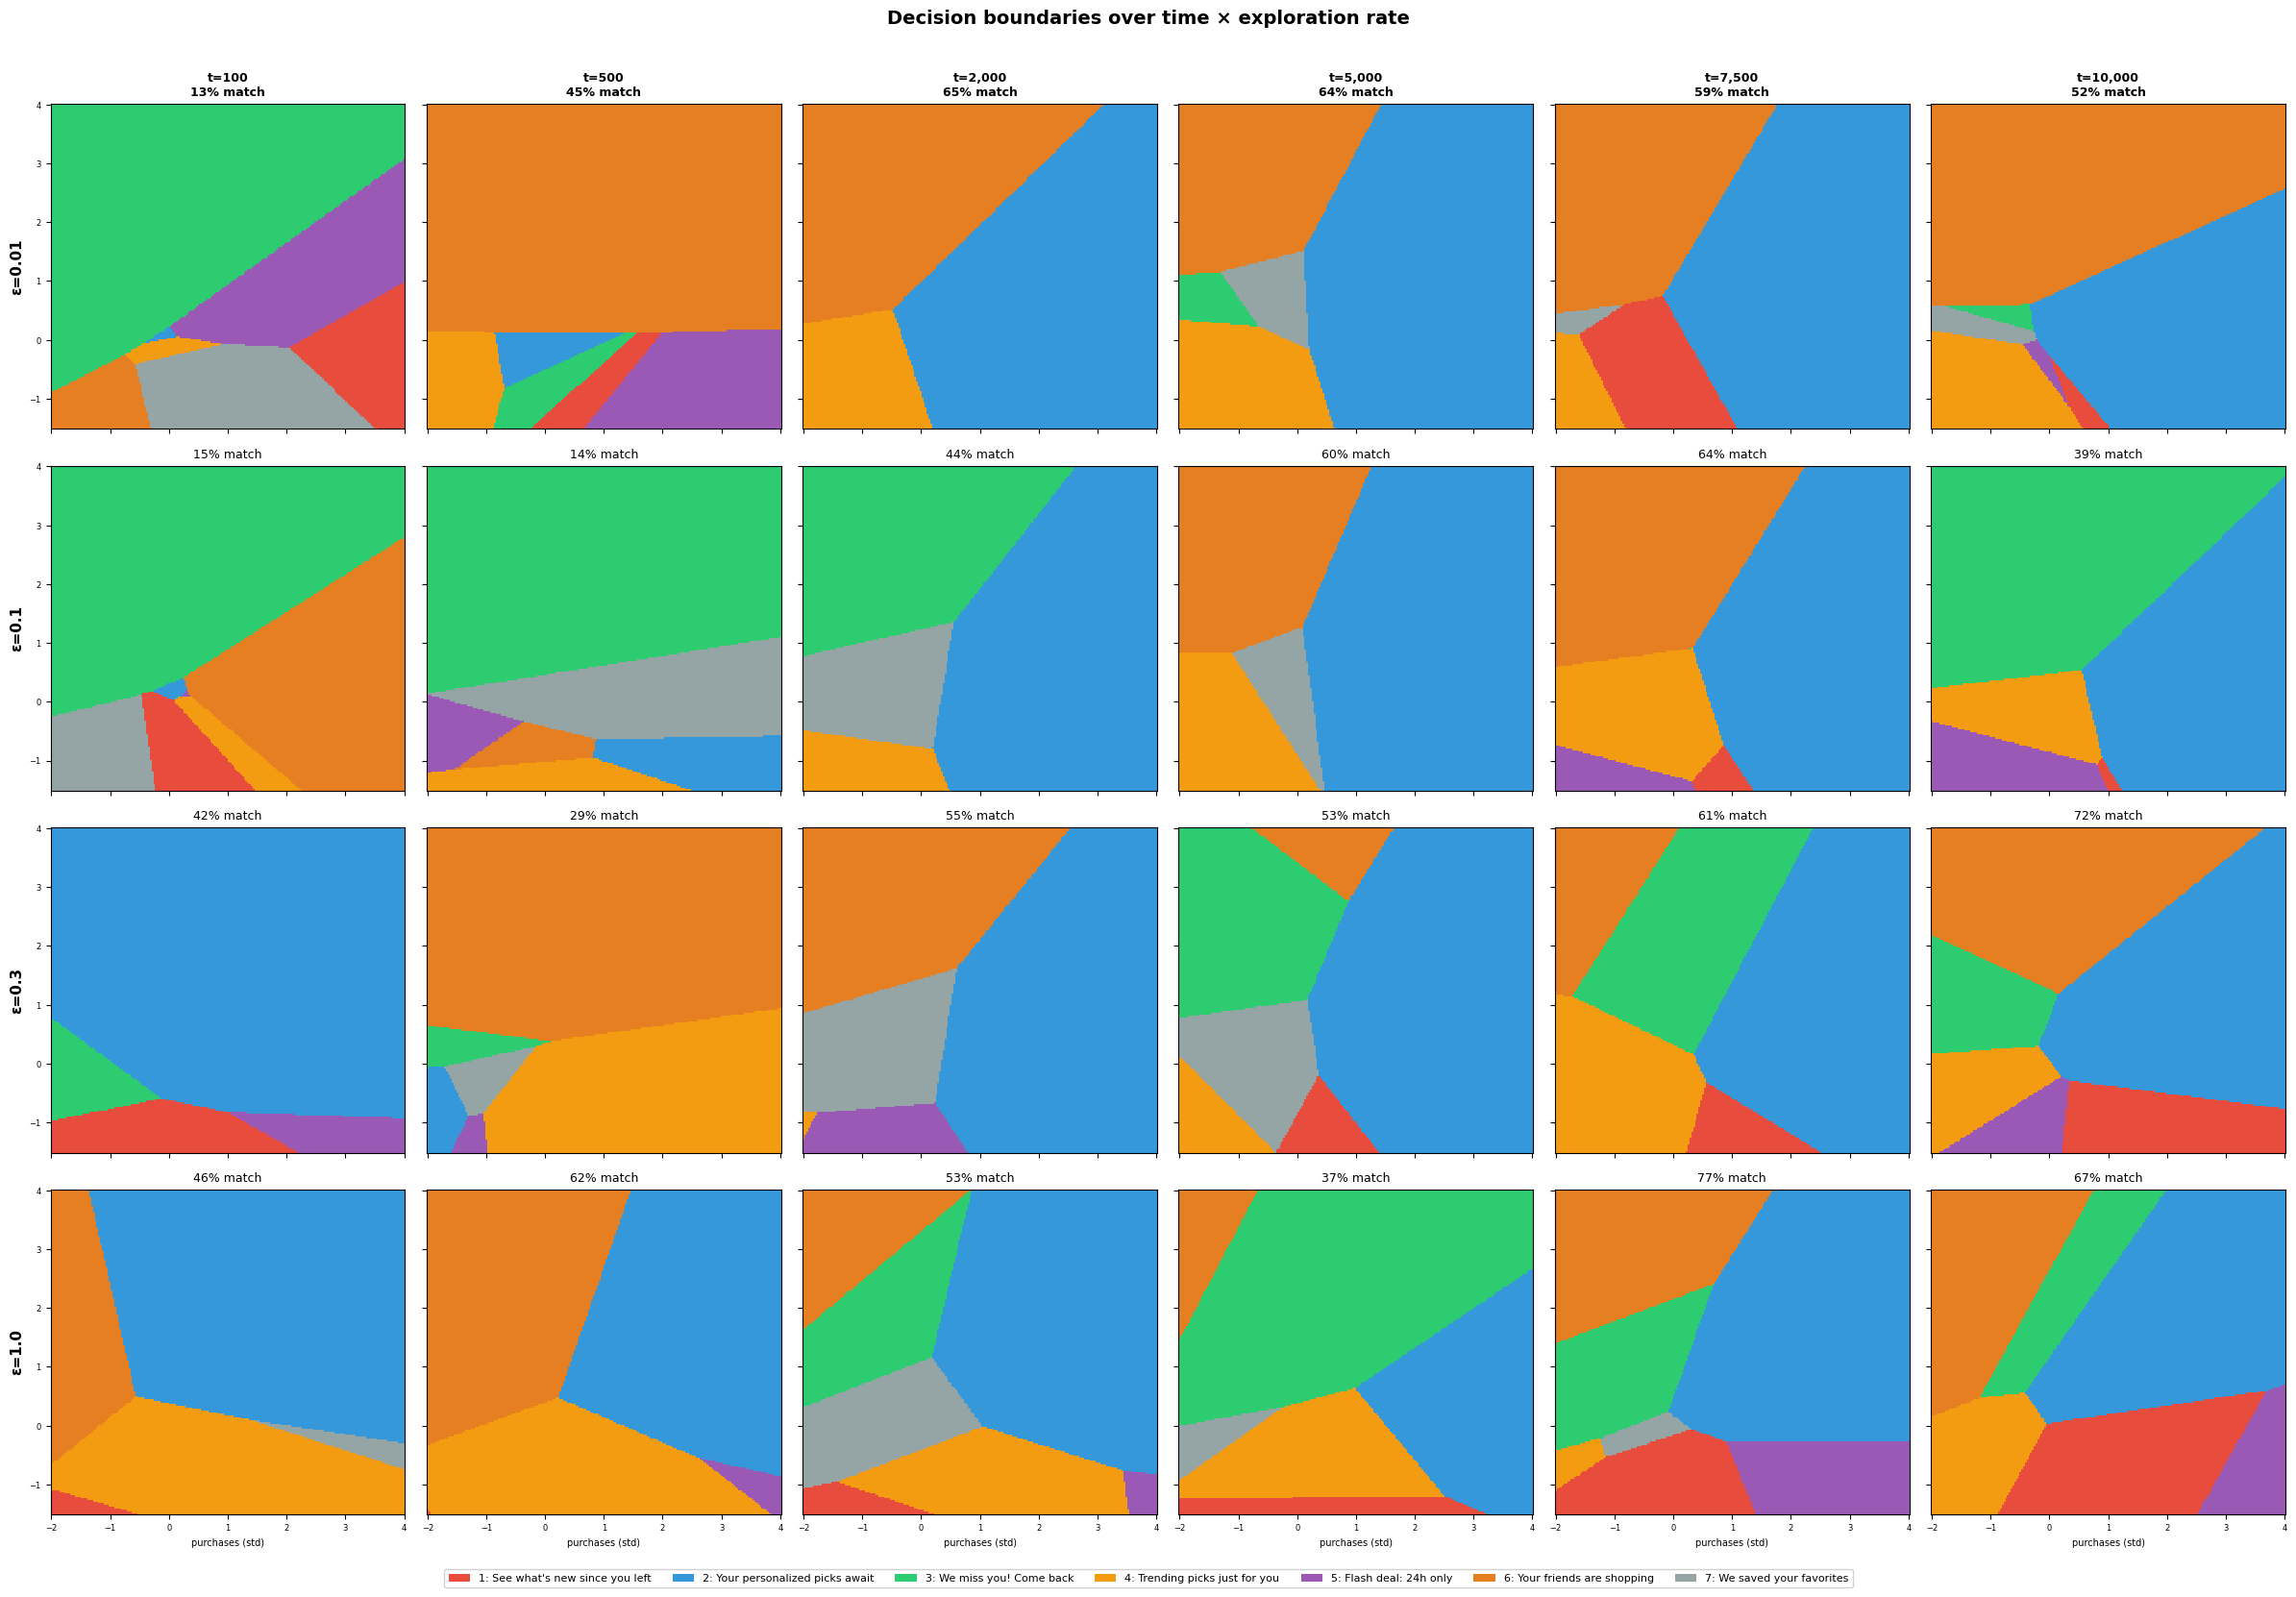

In [12]:
# Evolving decision boundaries across exploration strategies.
#
# Each row is a different ε value; each column is a time checkpoint.
# This shows how exploration rate affects the speed and quality of
# learning the oracle's decision regions.

eps_values = [0.01, 0.1, 0.3, 1.0]
checkpoints = [100, 500, 2000, 5000, 7500,10000]
N_ROUNDS = max(checkpoints)

all_snapshots = {}
for eps in eps_values:
    model_viz = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)
    env_viz2 = BanditEnv(seed=42)
    snaps = {}
    for t in range(1, N_ROUNDS + 1):
        x, _ = env_viz2.sample_context()
        action, prop = model_viz.sample_action(x, eps, env_viz2.rng)
        click = env_viz2.sample_click(x, action)
        model_viz.update(x, action, click, prop, method='direct')
        if t in checkpoints:
            snaps[t] = model_viz.W.copy()
    all_snapshots[eps] = snaps

# Evaluation grid
ps_grid = np.linspace(-2, 4, 200)
ds_grid = np.linspace(-1.5, 4, 200)
P, D = np.meshgrid(ps_grid, ds_grid)
x_grid = np.column_stack([np.ones(P.size), P.ravel(), D.ravel()])

logits_oracle = x_grid @ W_TRUE.T
best_oracle = (np.argmax(logits_oracle, axis=1) + 1).reshape(P.shape)

cmap = ListedColormap(ACTION_COLORS)
n_rows = len(eps_values)
n_cols = len(checkpoints)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

for row, eps in enumerate(eps_values):
    for col, t_snap in enumerate(checkpoints):
        ax = axes[row, col]
        W = all_snapshots[eps][t_snap]
        logits = x_grid @ W.T
        best = (np.argmax(logits, axis=1) + 1).reshape(P.shape)
        agreement = np.mean(best == best_oracle) * 100

        ax.pcolormesh(ps_grid, ds_grid, best, cmap=cmap,
                      vmin=0.5, vmax=K + 0.5, shading='auto')
        ax.set_title(f'{agreement:.0f}% match', fontsize=9)
        ax.tick_params(labelsize=6)

        if row == 0:
            ax.set_title(f't={t_snap:,}\n{agreement:.0f}% match',
                         fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'ε={eps}', fontsize=11, fontweight='bold')
        else:
            ax.set_yticklabels([])
        if row == n_rows - 1:
            ax.set_xlabel('purchases (std)', fontsize=7)
        else:
            ax.set_xticklabels([])

legend_elements = [
    Patch(facecolor=ACTION_COLORS[a - 1], label=f"{a}: {ACTION_NAMES[a]}")
    for a in range(1, K + 1)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=K,
           fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Decision boundaries over time × exploration rate',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 5. Cumulative CTR vs. policy quality — the exploration tax

Sections 3 and 4 reveal an apparent contradiction:

| | Cumulative CTR (§3) | Oracle agreement (§4) |
|---|---|---|
| $\varepsilon=0.01$ | **highest** | ~51% |
| $\varepsilon=0.3$ | mid-pack | **~72%** (highest) |

How can the strategy with the *worst* policy quality have the *best* cumulative CTR?

**The answer is the exploration tax.** Cumulative CTR measures the *blended* outcome of learning and serving simultaneously. Every round that $\varepsilon=0.3$ explores (30% of rounds), it picks a random action — pulling its realised CTR toward the random baseline, regardless of how good its learned policy is. With $K=7$ actions, random exploration is especially costly because most variants are suboptimal for most users. Meanwhile $\varepsilon=0.01$ exploits 99% of the time, extracting value from whatever it has learned, even if that policy is suboptimal.

The 30% exploration tax overwhelms the policy quality advantage.

**The right test:** freeze each model after training and evaluate it *greedily* ($\varepsilon \approx 0$) on fresh data. This separates policy quality from exploration cost — and the ranking should flip.

  Training ε   Cumul CTR   Greedy eval   Gap to oracle
--------------------------------------------------------
        0.01      0.1680        0.1714          0.0181
        0.10      0.1635        0.1749          0.0145
        0.30      0.1509        0.1840          0.0055
        1.00      0.1106        0.1789          0.0106


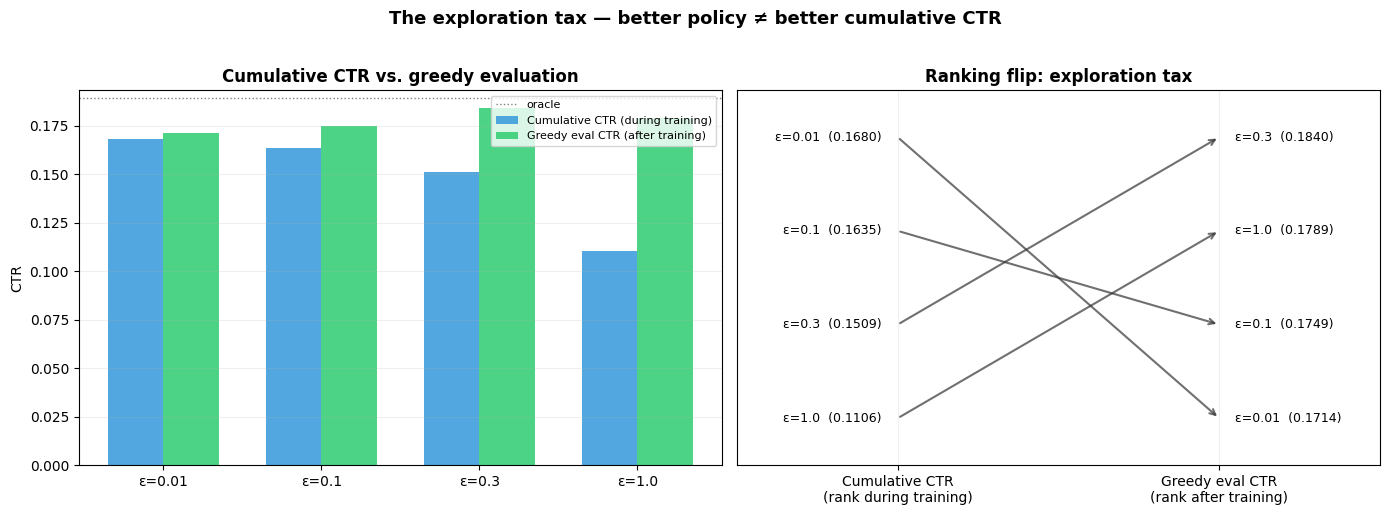


Oracle CTR: 0.1895
Best cumulative CTR:  ε=0.01 (0.1680)
Best greedy eval CTR: ε=0.3 (0.1840)


In [13]:
def eval_greedy(model, seed=999, N=20_000):
    """Evaluate a trained model greedily on fresh data."""
    env = BanditEnv(seed=seed)
    clicks = 0
    for _ in range(N):
        x, _ = env.sample_context()
        action, _ = model.sample_action(x, 0.001, env.rng)
        clicks += env.sample_click(x, action)
    return clicks / N


oracle_ctr = BanditEnv(seed=0).oracle_ctr(N=20_000)
train_epsilons = [0.01, 0.1, 0.3, 1.0]

results = []
for eps in train_epsilons:
    model = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)
    env = BanditEnv(seed=42)
    clicks = 0
    for t in range(10_000):
        x, _ = env.sample_context()
        action, prop = model.sample_action(x, eps, env.rng)
        click = env.sample_click(x, action)
        model.update(x, action, click, prop, method='direct')
        clicks += click
    cum_ctr = clicks / 10_000
    greedy_ctr = eval_greedy(model)
    results.append((eps, cum_ctr, greedy_ctr))

print(f"{'Training ε':>12s}  {'Cumul CTR':>10s}  {'Greedy eval':>12s}  {'Gap to oracle':>14s}")
print('-' * 56)
for eps, cum, greedy in results:
    print(f'{eps:>12.2f}  {cum:>10.4f}  {greedy:>12.4f}  {oracle_ctr - greedy:>14.4f}')

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = [f'ε={eps}' for eps in train_epsilons]
cum_vals = [r[1] for r in results]
greedy_vals = [r[2] for r in results]
x_pos = np.arange(len(labels))
bar_w = 0.35

ax1.bar(x_pos - bar_w/2, cum_vals, bar_w, label='Cumulative CTR (during training)',
        color='#3498db', alpha=0.85)
ax1.bar(x_pos + bar_w/2, greedy_vals, bar_w, label='Greedy eval CTR (after training)',
        color='#2ecc71', alpha=0.85)
ax1.axhline(oracle_ctr, color='black', ls=':', lw=1, alpha=0.5, label='oracle')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_ylabel('CTR')
ax1.set_title('Cumulative CTR vs. greedy evaluation', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.2)

# Highlight the ranking flip
cum_rank = np.argsort(cum_vals)[::-1]
greedy_rank = np.argsort(greedy_vals)[::-1]

for i, eps in enumerate(train_epsilons):
    ax2.annotate('', xy=(1, greedy_rank.tolist().index(i)),
                 xytext=(0, cum_rank.tolist().index(i)),
                 arrowprops=dict(arrowstyle='->', color='#333', lw=1.5, alpha=0.7))

for i, idx in enumerate(cum_rank):
    ax2.text(-0.05, i, f'{labels[idx]}  ({cum_vals[idx]:.4f})',
             ha='right', va='center', fontsize=9)
for i, idx in enumerate(greedy_rank):
    ax2.text(1.05, i, f'{labels[idx]}  ({greedy_vals[idx]:.4f})',
             ha='left', va='center', fontsize=9)

ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, len(train_epsilons) - 0.5)
ax2.invert_yaxis()
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Cumulative CTR\n(rank during training)',
                      'Greedy eval CTR\n(rank after training)'])
ax2.set_yticks([])
ax2.set_title('Ranking flip: exploration tax', fontweight='bold')
ax2.grid(axis='x', alpha=0.2)

fig.suptitle('The exploration tax — better policy ≠ better cumulative CTR',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nOracle CTR: {oracle_ctr:.4f}')
print(f'Best cumulative CTR:  ε={results[np.argmax(cum_vals)][0]} ({max(cum_vals):.4f})')
print(f'Best greedy eval CTR: ε={results[np.argmax(greedy_vals)][0]} ({max(greedy_vals):.4f})')


## 6. Learning method comparison: direct vs. IPS vs. DR

Our `LinearBanditModel` supports three update methods. How do they compare in online learning?

| Method | Update rule | Key property |
|--------|------------|-------------|
| **Direct** | $\Delta w_a = \alpha (\hat p - y)\, x$ | Only updates chosen action; low variance |
| **IPS** | $\Delta w_a = \frac{\alpha}{\pi(a)}(\hat p - y)\, x$ | Propensity-weighted; unbiased under policy shift, but high variance |
| **DR** | Combines direct reward model + IPS correction | Variance-reduced IPS; uses a separate reward model for counterfactual estimates |

### What to expect

In our **online learning** setup — where the model collects its own data at every step — **direct and DR should perform similarly**, and both should beat IPS. Here's why:

- **Direct works well here** because there's no policy mismatch. The model learns from data generated by its own current policy, so the gradient $(\hat p - y) \cdot x$ is naturally aligned with improving the current policy.

- **IPS suffers from propensity weight explosion.** With $\varepsilon=0.1$ and $K=7$, the greedy action has propensity $\approx 0.914$, but random actions have propensity $\approx 0.014$. IPS upweights these rare observations by $1/0.014 \approx 70\times$, creating massive gradient spikes that destabilise learning.

- **DR recovers from IPS's variance** — the reward model baseline absorbs most of the variance, so the IPS correction only needs to handle the residual. But it can't improve on direct because there's no bias to correct in the online setting.

### When would DR actually help?

DR's "doubly robust" property (consistent if *either* the reward model or the propensities are correct) shines in **off-policy / batch learning** — the more common production scenario:

- You inherit a dataset of logged interactions from a previous system (different policy)
- You want to train a new model on this historical data
- Direct learning on someone else's data is biased toward their action preferences
- DR corrects for this distribution mismatch while keeping variance manageable

In short: **direct is the right choice for online learning; DR is the right choice for off-policy batch learning.**

  direct    final cumulative CTR = 0.1635
  ips       final cumulative CTR = 0.1432
  dr        final cumulative CTR = 0.1559


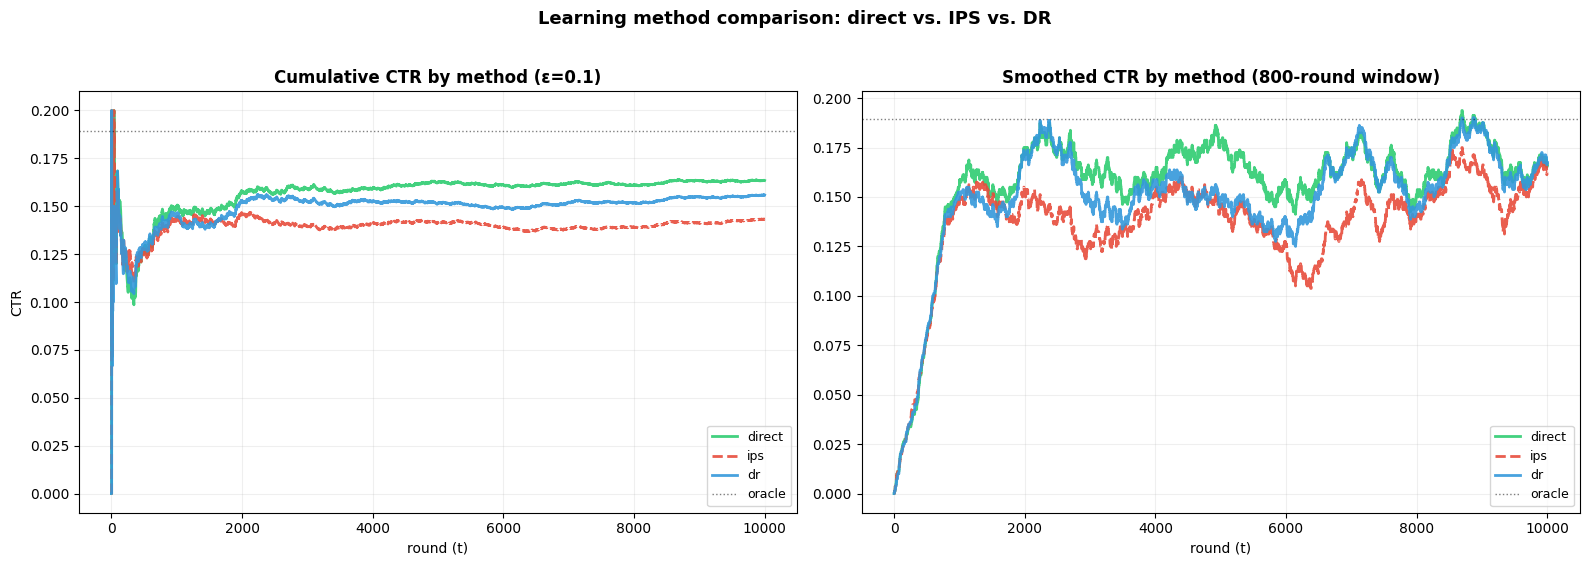


Greedy evaluation (freeze model, deploy at ε≈0):
    Method   Greedy CTR   Gap to oracle
----------------------------------------
    direct       0.1749          0.0145
       ips       0.1584          0.0310
        dr       0.1773          0.0121


In [14]:
# Compare learning methods at fixed ε=0.1.

EPS_METHOD = 0.1
N_METHOD = 10_000

def run_method_comparison(env_seed, N, epsilon, method='direct', lr=0.1):
    """Like run_with_tracking but handles DR's reward model."""
    model = LinearBanditModel(n_actions=K, n_features=3, lr=lr)
    env = BanditEnv(seed=env_seed)
    reward_model = LinearBanditModel(n_actions=K, n_features=3, lr=lr) if method == 'dr' else None
    clicks = 0
    cumulative_ctr = np.zeros(N)
    raw_clicks = np.zeros(N, dtype=np.float64)
    for t in range(N):
        x, _ = env.sample_context()
        action, prop = model.sample_action(x, epsilon, env.rng)
        click = env.sample_click(x, action)
        if method == 'dr':
            model.update(x, action, click, prop, method='dr', reward_model=reward_model)
            reward_model.update(x, action, click, prop, method='direct')
        else:
            model.update(x, action, click, prop, method=method)
        clicks += click
        cumulative_ctr[t] = clicks / (t + 1)
        raw_clicks[t] = click
    return cumulative_ctr, raw_clicks, model


methods = {
    'direct': ('#2ecc71', '-'),
    'ips':    ('#e74c3c', '--'),
    'dr':     ('#3498db', '-'),
}

fig, (ax_cum, ax_smooth) = plt.subplots(1, 2, figsize=(16, 5.5))
ts = np.arange(1, N_METHOD + 1)
oracle_ctr = BanditEnv(seed=0).oracle_ctr(N=20_000)

method_models = {}
for method_name, (color, ls) in methods.items():
    cum, raw, mdl = run_method_comparison(SEED, N_METHOD, EPS_METHOD, method=method_name)
    method_models[method_name] = mdl
    ax_cum.plot(ts, cum, label=method_name, color=color, ls=ls, lw=2, alpha=0.9)
    ax_smooth.plot(ts, smooth(raw, SMOOTH_WINDOW), label=method_name,
                   color=color, ls=ls, lw=2, alpha=0.9)
    print(f'  {method_name:8s}  final cumulative CTR = {cum[-1]:.4f}')

for ax in (ax_cum, ax_smooth):
    ax.axhline(oracle_ctr, color='black', ls=':', lw=1, alpha=0.5, label='oracle')
    ax.set_xlabel('round (t)')
    ax.grid(alpha=0.2)

ax_cum.set_ylabel('CTR')
ax_cum.set_title(f'Cumulative CTR by method (ε={EPS_METHOD})', fontweight='bold')
ax_cum.legend(fontsize=9)

ax_smooth.set_title(f'Smoothed CTR by method ({SMOOTH_WINDOW}-round window)',
                    fontweight='bold')
ax_smooth.legend(fontsize=9)

fig.suptitle('Learning method comparison: direct vs. IPS vs. DR',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Greedy evaluation
print(f'\nGreedy evaluation (freeze model, deploy at ε≈0):')
print(f'{"Method":>10s}  {"Greedy CTR":>11s}  {"Gap to oracle":>14s}')
print('-' * 40)
for method_name, mdl in method_models.items():
    greedy_ctr = eval_greedy(mdl)
    print(f'{method_name:>10s}  {greedy_ctr:>11.4f}  {oracle_ctr - greedy_ctr:>14.4f}')


## 7. Why $\varepsilon$-greedy wastes data — and what comes next

### The gradient informativeness problem

Our update rule is $\Delta w_a = \alpha\,(\hat p - y)\, x$. The learning signal comes entirely from $|\hat p - y|$ — how "surprised" the model is by the outcome.

When $\varepsilon$-greedy explores randomly, ~75% of the time it picks the *wrong* action for a user. For these observations:

- True click probability is low ($p_{\text{true}} \approx 0.05$)
- After minimal training, the model's prediction is also low ($\hat p \approx 0.05$)
- The outcome is almost always $y=0$, giving gradient $(0.05 - 0) \cdot x = 0.05x$ — tiny

These observations are **confirmatory** — the model already knows this action doesn't work for this user segment, the user confirms it by not clicking, and the weight update is negligible. The data budget is spent on information the model already has.

This connects to a fundamental result in statistics: the **Fisher information** of a Bernoulli observation is $p(1-p)$, which is maximized at $p=0.5$ and approaches zero as $p \to 0$ or $p \to 1$. Observations in the tails carry almost no information. With random exploration, most observations land in the low-$p$ tail.

### The core limitation of $\varepsilon$-greedy

$\varepsilon$-greedy explores *uniformly* — it doesn't know (or care) which actions the model is uncertain about. It assigns the same exploration probability to:

- An action the model has seen 5,000 times and confidently predicts $\hat p = 0.03$
- An action the model has seen 50 times and has no idea whether $\hat p$ should be 0.05 or 0.15

A smarter strategy would direct exploration toward **uncertain** actions — where the gradient signal is most informative.

### More sophisticated exploration strategies

Two well-studied approaches address this directly:

**Thompson Sampling (TS):** Maintain a *posterior distribution* over each action's weights (not just a point estimate). At each round, *sample* weights from the posterior and act greedily w.r.t. the sample. When the model is uncertain about an action (wide posterior), the sample will sometimes make that action look best → natural exploration. When the model is confident (narrow posterior), the sample stays close to the mean → exploitation. The exploration is *proportional to uncertainty*.

**Upper Confidence Bound (UCB):** Compute an upper confidence bound for each action's expected reward: $\text{UCB}(a) = \hat{\mu}_a + \beta \cdot \sigma_a$, where $\sigma_a$ measures uncertainty. Pick the action with the highest UCB. Like TS, this explores uncertain actions more — but deterministically rather than stochastically.

Both methods have strong theoretical guarantees:
- TS achieves near-optimal *information ratio* — it extracts maximum learning per unit of regret (Russo & Van Roy, 2014)
- LinUCB achieves $\tilde{O}(d\sqrt{T})$ regret for linear bandits (Abbasi-Yadkori et al., 2011)

### What we'd expect to see

If we implemented TS or UCB in our environment, we'd expect:

1. **Faster convergence** of decision boundaries (fewer rounds to reach high oracle agreement)
2. **No ranking flip** — the strategy that learns the best policy *also* has the best cumulative CTR, because exploration is targeted rather than wasted
3. **Better scaling with noise** — directed exploration is especially valuable when rewards are noisy, because it avoids spending the data budget on uninformative observations

These are natural next steps for a production bandit system. The $\varepsilon$-greedy approach we've built here is a strong pedagogical foundation — it exposes all the tradeoffs clearly — but in practice, Thompson Sampling is the most common choice for contextual bandits at scale.

## 8. From bandits to causal inference

Everything we've built so far is secretly a **causal model**. The bandit doesn't just predict clicks — it estimates *what would happen* if we intervened and sent a specific message to a specific user. This is the language of causal inference.

### The Potential Outcomes framework

In causal ML, we think in terms of **potential outcomes**. For each user $i$ and action $a$:

$$Y_i(a) \in \{0, 1\} \quad \text{— what would happen if user } i \text{ received message } a$$

The fundamental problem: we only observe $Y_i(a)$ for the action we actually chose. The outcomes for all other actions are **counterfactual** — they exist in principle, but we never see them. This is identical to bandit feedback.

### Mapping bandit concepts to causal ML

| Bandit term | Causal ML term | In our notebook |
|-------------|---------------|-----------------|
| Action $a$ | Treatment | Message variant |
| Reward $r$ | Outcome $Y$ | Click / no-click |
| Context $x$ | Covariates | User features |
| $\hat{p}(x, a)$ | Conditional outcome model $\hat{\mu}(x, a)$ | `model.predict_proba(x)` |
| Policy $\pi(a \mid x)$ | Treatment assignment rule | $\varepsilon$-greedy |
| Propensity $\pi(a \mid x)$ | Propensity score $e(a \mid x)$ | `model.action_probs(x, ε)` |
| IPS estimator | Horvitz–Thompson estimator | `ope_ips_snips()` |
| DR update | AIPW (Augmented IPW) estimator | `model.update(..., method='dr')` |
| Oracle policy | Optimal treatment regime | `env.oracle_action(x)` |

The **Average Treatment Effect (ATE)** of action $a$ vs. action $a'$ is:

$$\text{ATE}(a, a') = E\bigl[Y(a) - Y(a')\bigr]$$

But we care about something richer — the **Conditional Average Treatment Effect (CATE)**:

$$\tau(x;\, a, a') = E\bigl[Y(a) - Y(a') \mid X = x\bigr]$$

CATE tells us: *for a user with features $x$, how much better is message $a$ than message $a'$?*  Our bandit model estimates this directly:

$$\hat{\tau}(x;\, a, a') = \hat{p}(x, a) - \hat{p}(x, a')$$

The entire bandit learning process — exploration, reward feedback, weight updates — is an **online CATE estimation procedure**. The decision boundary we plotted in §4 is the set of points where $\hat{\tau}(x; a_{\text{best}}, a_{\text{second}}) = 0$.

### What this section covers

1. **Value of personalization** — How much does knowing user features actually help? We decompose the overall CTR lift into "what you gain from the best action" vs. "what you gain from personalizing."

2. **CATE heatmaps** — Visualize the estimated treatment effects across user segments, and compare the model's estimates to ground truth.

3. **Individual-level explanations** — For specific users, break down *why* the model chose a particular action into feature-level contributions.

4. **Counterfactual analysis** — "What would have happened if we'd sent a different message?" — the core causal question.

5. **Meta-learner taxonomy** — How our approach fits into the broader causal ML landscape (T-learners, S-learners, X-learners, R-learners).

### 8.1 Value of personalization

Before diving into individual treatment effects, let's answer the big-picture question: **how much does personalization actually help?**

We compare three policies on the same population:

| Policy | Description | Uses user features? |
|--------|-------------|-------------------|
| **Random** | Uniform random action | No |
| **Best single action** | Always send the single message with the highest population-average CTR | No |
| **Personalized (bandit)** | Use the learned model to pick the best action per user | Yes |
| **Oracle** | True best action per user (unknown in practice) | Yes (perfectly) |

The total lift of the oracle over random decomposes into two parts:

$$\underbrace{\text{Oracle} - \text{Random}}_{\text{total lift}} \;=\; \underbrace{\text{Best single} - \text{Random}}_{\text{action selection lift}} \;+\; \underbrace{\text{Oracle} - \text{Best single}}_{\text{personalization lift}}$$

The **action selection lift** comes from picking a good action *on average* — no ML needed, just an A/B test. The **personalization lift** is the value of *heterogeneous treatment effects* — knowing that different users respond to different messages. This is the part that justifies the complexity of a bandit system.

Population-average CTR per action (noiseless):
  1: See what's new since you left        CTR=0.0713
  2: Your personalized picks await        CTR=0.1244 ← best single
  3: We miss you! Come back               CTR=0.1018
  4: Trending picks just for you          CTR=0.0804
  5: Flash deal: 24h only                 CTR=0.0405
  6: Your friends are shopping            CTR=0.0743
  7: We saved your favorites              CTR=0.0947

Policy                     CTR   Lift vs random
------------------------------------------------
random                  0.0842          +0.0000
best_single             0.1249          +0.0407
bandit                  0.1486          +0.0644
oracle                  0.1544          +0.0702

Lift decomposition
  Total oracle lift:      +0.0702
  Action selection lift:  +0.0407  (58% of total)
  Personalization lift:   +0.0295  (42% of total)
  Bandit captures:        +0.0238  (80% of personalization lift)


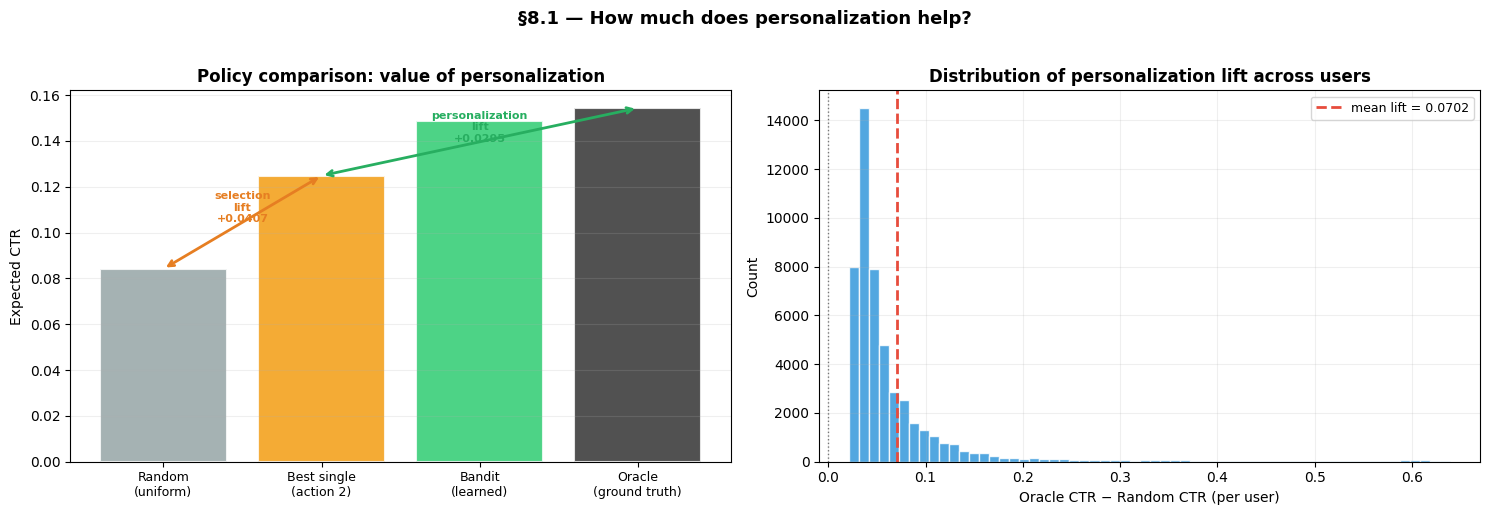

In [15]:
# Train a bandit model (ε=0.3 — our best exploration schedule from §5).
model_causal = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)
env_causal = BanditEnv(seed=42)
for t in range(10_000):
    x, _ = env_causal.sample_context()
    action, prop = model_causal.sample_action(x, 0.3, env_causal.rng)
    click = env_causal.sample_click(x, action)
    model_causal.update(x, action, click, prop, method='direct')

# Evaluate four policies on the same population.
N_EVAL = 50_000

def evaluate_policies(model, seed=999, N=N_EVAL):
    env = BanditEnv(seed=seed)

    # Find the best single action (population-average CTR per action).
    action_ctrs = np.zeros(K)
    env_pop = BanditEnv(seed=seed + 1)
    for _ in range(N):
        x, _ = env_pop.sample_context()
        for a in range(K):
            action_ctrs[a] += env_pop.click_prob(x, a + 1)
    action_ctrs /= N
    best_single = int(np.argmax(action_ctrs)) + 1

    results = {'random': 0, 'best_single': 0, 'bandit': 0, 'oracle': 0}
    per_user_lift = np.zeros(N)

    for i in range(N):
        x, _ = env.sample_context()
        p_oracle_action = env.oracle_action(x)

        p_random = np.mean([env.click_prob(x, a) for a in range(1, K + 1)])
        p_best_single = env.click_prob(x, best_single)
        p_bandit_action, _ = model.sample_action(x, 0.001, env.rng)
        p_bandit = env.click_prob(x, p_bandit_action)
        p_oracle = env.click_prob(x, p_oracle_action)

        results['random'] += p_random
        results['best_single'] += p_best_single
        results['bandit'] += p_bandit
        results['oracle'] += p_oracle
        per_user_lift[i] = p_oracle - p_random

    for k in results:
        results[k] /= N
    return results, best_single, action_ctrs, per_user_lift

results, best_single_action, pop_ctrs, per_user_lift = evaluate_policies(model_causal)

print("Population-average CTR per action (noiseless):")
for a in range(K):
    marker = " ← best single" if a + 1 == best_single_action else ""
    print(f"  {a+1}: {ACTION_NAMES[a+1]:35s}  CTR={pop_ctrs[a]:.4f}{marker}")

print(f"\n{'Policy':<20s}  {'CTR':>8s}  {'Lift vs random':>15s}")
print("-" * 48)
for policy in ['random', 'best_single', 'bandit', 'oracle']:
    lift = results[policy] - results['random']
    print(f"{policy:<20s}  {results[policy]:8.4f}  {lift:>+15.4f}")

# Decompose the lift.
total_lift = results['oracle'] - results['random']
selection_lift = results['best_single'] - results['random']
personalization_lift = results['oracle'] - results['best_single']
bandit_captured = results['bandit'] - results['best_single']

print(f"\n{'Lift decomposition':}")
print(f"  Total oracle lift:      {total_lift:+.4f}")
print(f"  Action selection lift:  {selection_lift:+.4f}  ({selection_lift/total_lift*100:.0f}% of total)")
print(f"  Personalization lift:   {personalization_lift:+.4f}  ({personalization_lift/total_lift*100:.0f}% of total)")
print(f"  Bandit captures:        {bandit_captured:+.4f}  ({bandit_captured/personalization_lift*100:.0f}% of personalization lift)")

# Visualization.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: bar chart of policy CTRs with lift decomposition.
policies = ['random', 'best_single', 'bandit', 'oracle']
labels = ['Random\n(uniform)', f'Best single\n(action {best_single_action})',
          'Bandit\n(learned)', 'Oracle\n(ground truth)']
colors = ['#95a5a6', '#f39c12', '#2ecc71', '#333333']
ctrs = [results[p] for p in policies]

bars = ax1.bar(range(4), ctrs, color=colors, alpha=0.85, edgecolor='white', lw=1.5)
ax1.set_xticks(range(4))
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('Expected CTR')
ax1.set_title('Policy comparison: value of personalization', fontweight='bold')
ax1.grid(axis='y', alpha=0.2)

ax1.annotate('', xy=(1, results['best_single']), xytext=(0, results['random']),
             arrowprops=dict(arrowstyle='<->', color='#e67e22', lw=2))
ax1.text(0.5, (results['random'] + results['best_single']) / 2,
         f'selection\nlift\n{selection_lift:+.4f}',
         ha='center', fontsize=8, color='#e67e22', fontweight='bold')

ax1.annotate('', xy=(3, results['oracle']), xytext=(1, results['best_single']),
             arrowprops=dict(arrowstyle='<->', color='#27ae60', lw=2))
ax1.text(2.0, (results['best_single'] + results['oracle']) / 2,
         f'personalization\nlift\n{personalization_lift:+.4f}',
         ha='center', fontsize=8, color='#27ae60', fontweight='bold')

# Right: distribution of per-user lift (oracle - random).
ax2.hist(per_user_lift, bins=60, color='#3498db', alpha=0.85, edgecolor='white')
ax2.axvline(np.mean(per_user_lift), color='#e74c3c', ls='--', lw=2,
            label=f'mean lift = {np.mean(per_user_lift):.4f}')
ax2.axvline(0, color='black', ls=':', lw=1, alpha=0.5)
ax2.set_xlabel('Oracle CTR − Random CTR (per user)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of personalization lift across users', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)

fig.suptitle('§8.1 — How much does personalization help?',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 8.2 CATE estimation — treatment effect heterogeneity

The **Conditional Average Treatment Effect** answers: *for this specific user, how much better is action $a$ than action $a'$?*

$$\hat{\tau}(x;\, a, a') = \hat{p}(x, a) - \hat{p}(x, a')$$

For our linear model, this has a clean closed-form:

$$\hat{\tau}(x;\, a, a') = \sigma(w_a \cdot x) - \sigma(w_{a'} \cdot x)$$

CATE is the workhorse of **heterogeneous treatment effect (HTE)** estimation — a major subfield of causal ML. The key insight: treatment effects are not constant. The *same* treatment can help one subpopulation and hurt another. In our context: a message that works great for loyal veterans might be counterproductive for one-and-done users.

Below we visualize the estimated CATE for several action pairs, comparing what the **bandit learned** vs. the **ground truth**. Perfect learning would mean identical heatmaps.

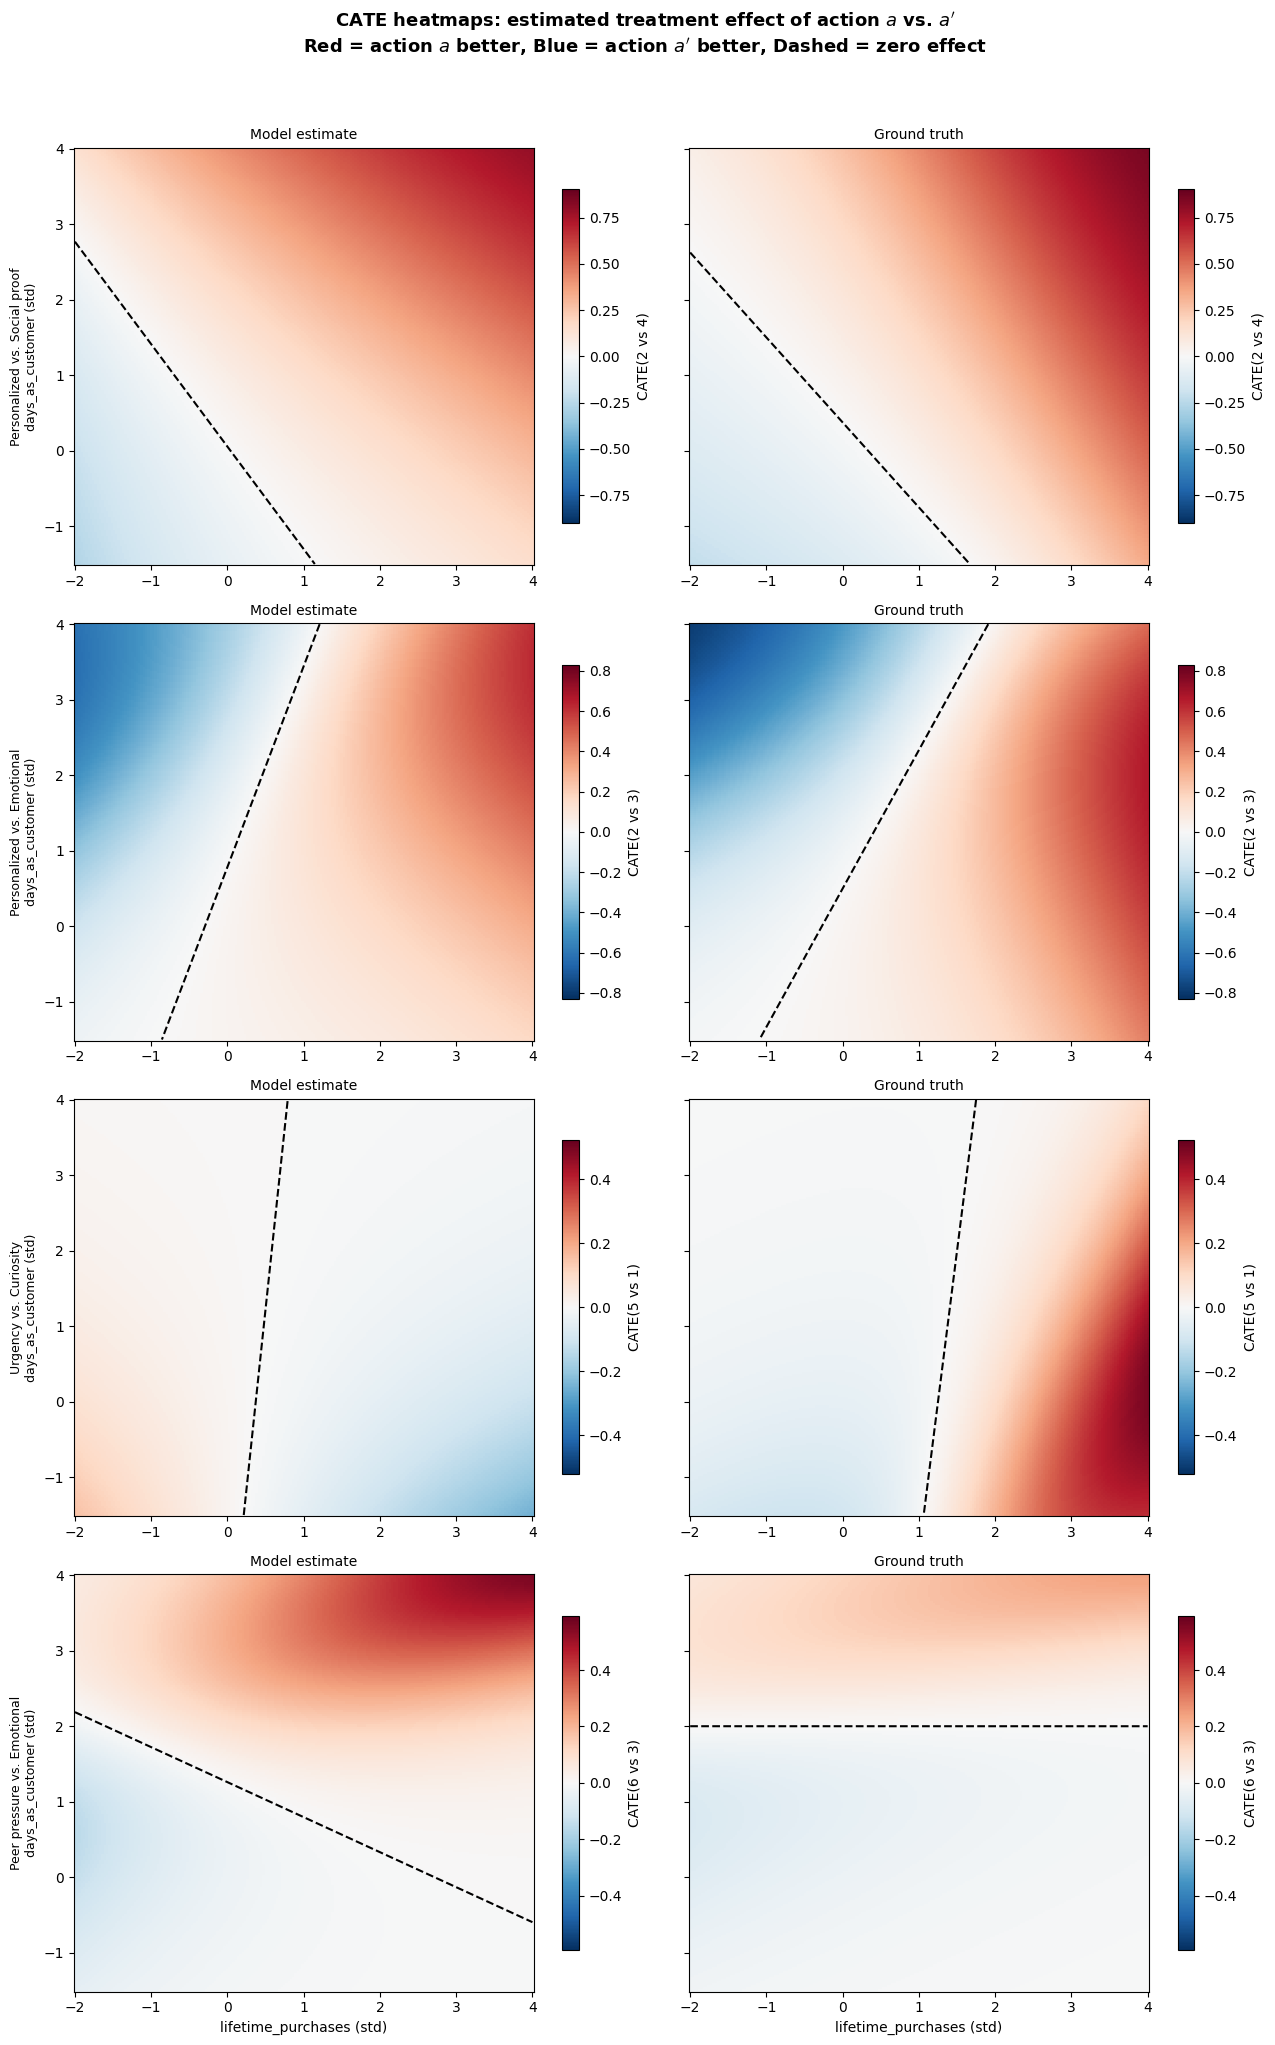

Model–oracle CATE correlation (Pearson r) by action pair:
  2 vs 4 (Personalized vs. Social proof      ):  r = 0.957
  2 vs 3 (Personalized vs. Emotional         ):  r = 0.957
  5 vs 1 (Urgency vs. Curiosity              ):  r = -0.831
  6 vs 3 (Peer pressure vs. Emotional        ):  r = 0.915


In [16]:
# CATE heatmaps: model-estimated vs. oracle (ground truth).

ps_grid = np.linspace(-2, 4, 200)
ds_grid = np.linspace(-1.5, 4, 200)
P_g, D_g = np.meshgrid(ps_grid, ds_grid)
x_grid = np.column_stack([np.ones(P_g.size), P_g.ravel(), D_g.ravel()])

# Compute model-estimated and oracle CTR for every (x, action).
model_ctrs = sigmoid(x_grid @ model_causal.W.T)     # shape (N_grid, K)
oracle_ctrs = sigmoid(x_grid @ W_TRUE.T)             # shape (N_grid, K)

# Pick interesting action pairs to compare.
action_pairs = [
    (2, 4, "Personalized vs. Social proof"),
    (2, 3, "Personalized vs. Emotional"),
    (5, 1, "Urgency vs. Curiosity"),
    (6, 3, "Peer pressure vs. Emotional"),
]

fig, axes = plt.subplots(len(action_pairs), 2, figsize=(13, 5 * len(action_pairs)))

for row, (a1, a2, title) in enumerate(action_pairs):
    cate_model = (model_ctrs[:, a1-1] - model_ctrs[:, a2-1]).reshape(P_g.shape)
    cate_oracle = (oracle_ctrs[:, a1-1] - oracle_ctrs[:, a2-1]).reshape(P_g.shape)

    vabs = max(np.abs(cate_oracle).max(), np.abs(cate_model).max()) * 1.05

    for col, (data, label) in enumerate([(cate_model, 'Model estimate'),
                                          (cate_oracle, 'Ground truth')]):
        ax = axes[row, col]
        im = ax.pcolormesh(ps_grid, ds_grid, data, cmap='RdBu_r',
                           vmin=-vabs, vmax=vabs, shading='auto')
        ax.contour(ps_grid, ds_grid, data, levels=[0], colors='black',
                   linewidths=1.5, linestyles='--')
        ax.set_title(f'{label}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{title}\ndays_as_customer (std)', fontsize=9)
        else:
            ax.set_yticklabels([])
        if row == len(action_pairs) - 1:
            ax.set_xlabel('lifetime_purchases (std)')
        plt.colorbar(im, ax=ax, label=f'CATE({a1} vs {a2})', shrink=0.8)

fig.suptitle('CATE heatmaps: estimated treatment effect of action $a$ vs. $a\'$\n'
             'Red = action $a$ better, Blue = action $a\'$ better, Dashed = zero effect',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics: correlation between model and oracle CATE.
print("Model–oracle CATE correlation (Pearson r) by action pair:")
for a1, a2, title in action_pairs:
    cate_m = model_ctrs[:, a1-1] - model_ctrs[:, a2-1]
    cate_o = oracle_ctrs[:, a1-1] - oracle_ctrs[:, a2-1]
    r = np.corrcoef(cate_m, cate_o)[0, 1]
    print(f"  {a1} vs {a2} ({title:35s}):  r = {r:.3f}")

### 8.3 Individual-level explanations

In production, stakeholders ask: *"Why did the model send this user message 2 instead of message 4?"*

For our linear model, the answer is fully transparent. The score for action $a$ is:

$$\text{logit}_a = w_{a,0} + w_{a,1} \cdot \text{purchases\_std} + w_{a,2} \cdot \text{days\_std}$$

Each term is an additive **feature contribution**. The model picked the action with the highest logit, so we can show exactly which features pushed the decision.

This is the linear-model equivalent of **SHAP values** (SHapley Additive exPlanations). For linear models, SHAP values *are* the feature contributions — no approximation needed. In production with nonlinear models, you'd use `shap.Explainer` to get the same decomposition.

Below, we pick a few representative users and show a "waterfall" breakdown of the model's reasoning.

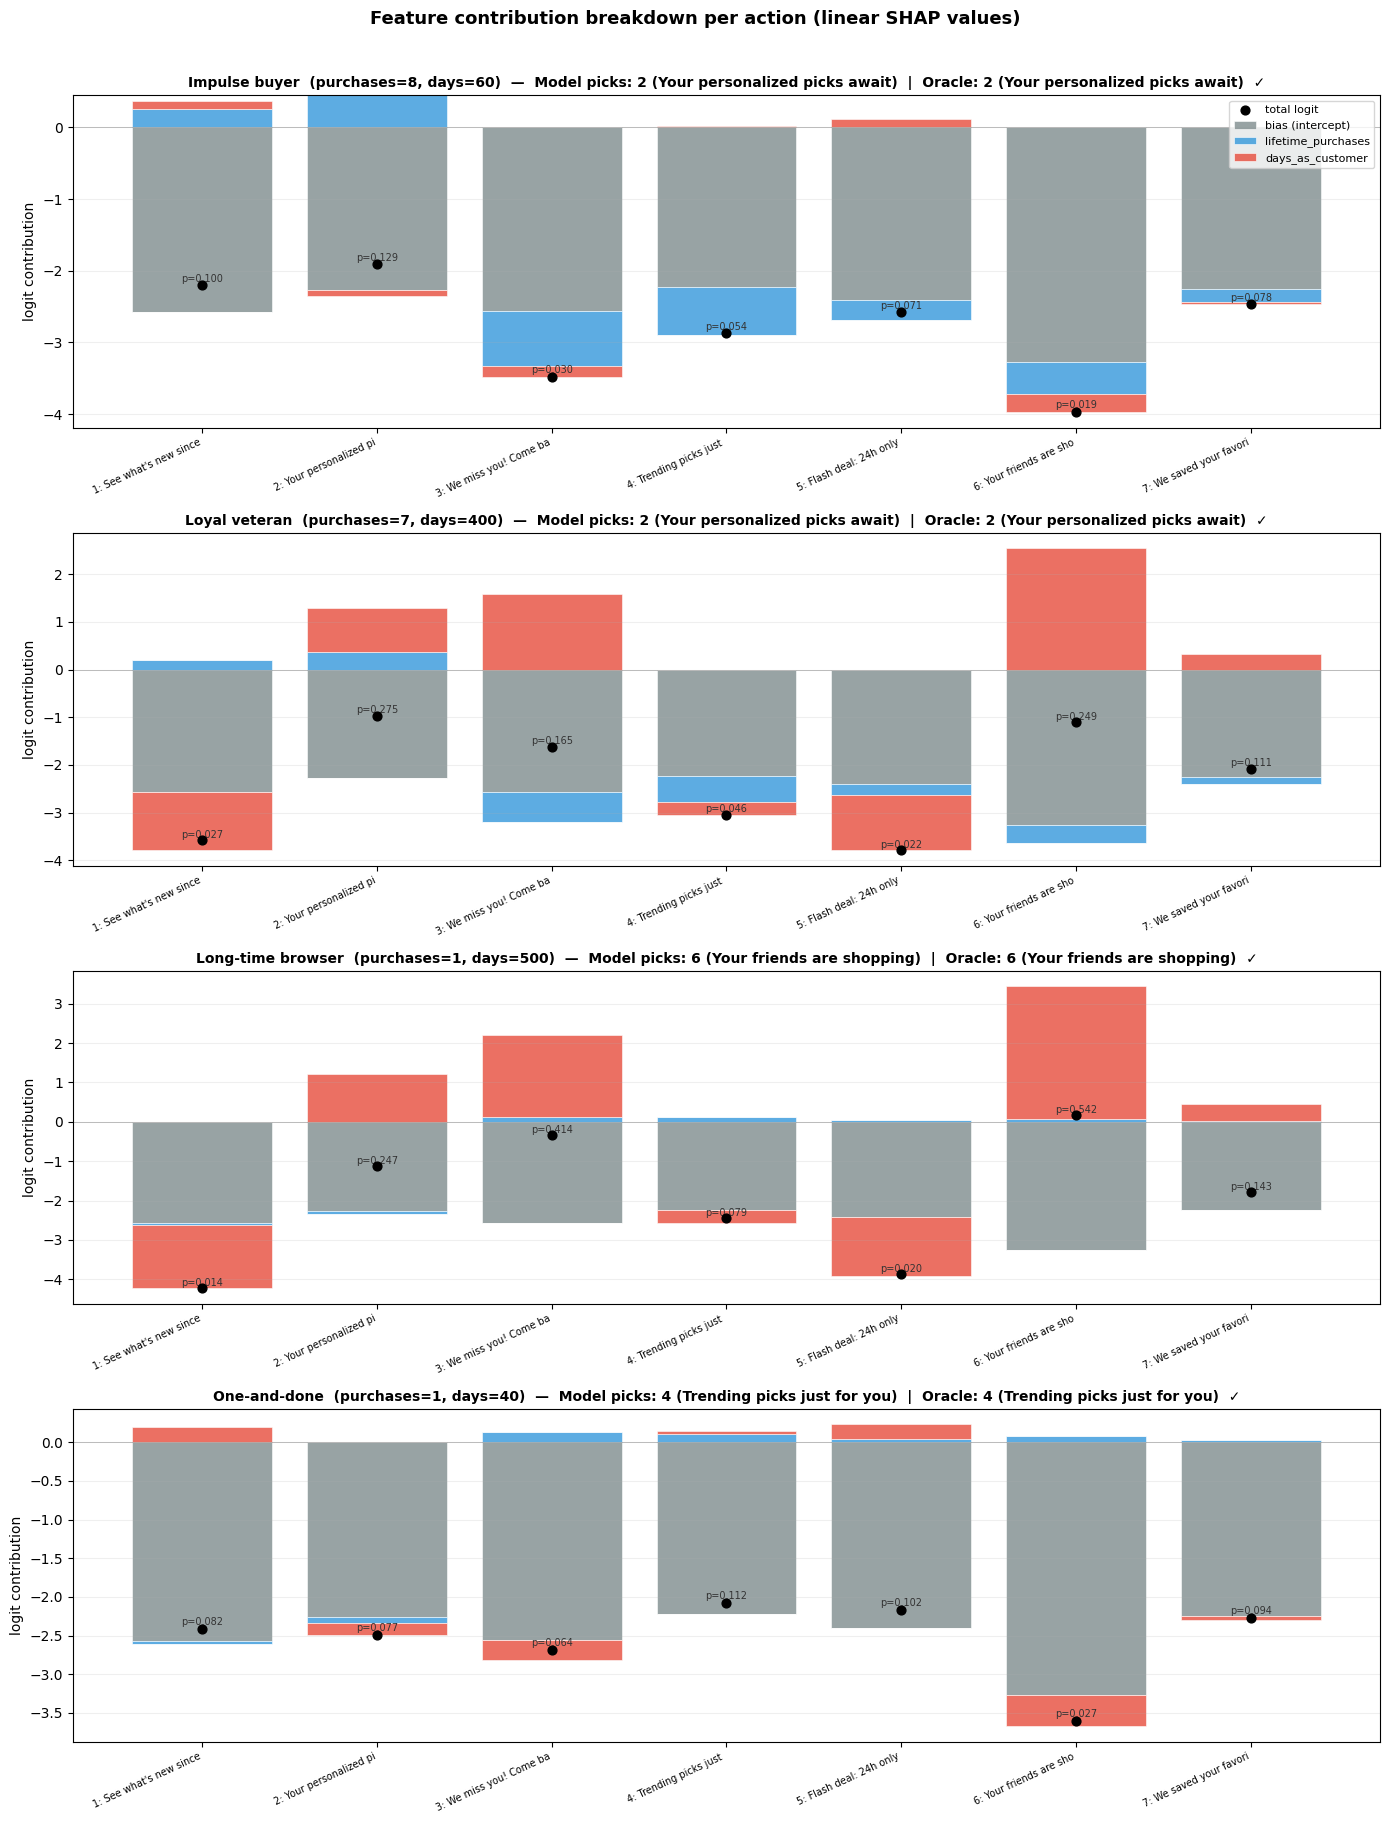

In [17]:
# Individual explanations: feature contribution waterfall.

feature_labels = ['bias (intercept)', 'lifetime_purchases', 'days_as_customer']

representative_users = [
    {"lifetime_purchases": 8, "days_as_customer": 60,  "label": "Impulse buyer"},
    {"lifetime_purchases": 7, "days_as_customer": 400, "label": "Loyal veteran"},
    {"lifetime_purchases": 1, "days_as_customer": 500, "label": "Long-time browser"},
    {"lifetime_purchases": 1, "days_as_customer": 40,  "label": "One-and-done"},
]

fig, axes = plt.subplots(len(representative_users), 1,
                         figsize=(14, 4.5 * len(representative_users)))

for row, user in enumerate(representative_users):
    ax = axes[row]
    ps = FEATURE_STATS["lifetime_purchases"]
    ds = FEATURE_STATS["days_as_customer"]
    x = np.array([1.0,
                  (user["lifetime_purchases"] - ps["mean"]) / ps["std"],
                  (user["days_as_customer"] - ds["mean"]) / ds["std"]])

    logits = model_causal.W @ x
    chosen = int(np.argmax(logits))
    probs = sigmoid(logits)
    oracle_a = env.oracle_action(x) - 1

    contributions = model_causal.W * x[np.newaxis, :]  # shape (K, 3)

    x_pos = np.arange(K)
    bottom_pos = np.zeros(K)
    bottom_neg = np.zeros(K)

    colors_feat = ['#7f8c8d', '#3498db', '#e74c3c']
    hatches = ['', '//', '\\\\']
    for f_idx in range(3):
        vals = contributions[:, f_idx]
        pos = np.where(vals >= 0, vals, 0)
        neg = np.where(vals < 0, vals, 0)
        ax.bar(x_pos, pos, bottom=bottom_pos, color=colors_feat[f_idx],
               alpha=0.8, label=feature_labels[f_idx], edgecolor='white', lw=0.5)
        ax.bar(x_pos, neg, bottom=bottom_neg, color=colors_feat[f_idx],
               alpha=0.8, edgecolor='white', lw=0.5)
        bottom_pos += pos
        bottom_neg += neg

    ax.scatter(x_pos, logits, color='black', zorder=5, s=40, label='total logit')

    ax.axhline(0, color='black', lw=0.5, alpha=0.3)

    action_labels = [f"{a+1}: {ACTION_NAMES[a+1][:20]}" for a in range(K)]
    ax.set_xticks(x_pos)
    ax.set_xticklabels(action_labels, fontsize=7, rotation=25, ha='right')
    ax.set_ylabel('logit contribution')

    chosen_str = f"Model picks: {chosen+1} ({ACTION_NAMES[chosen+1]})"
    oracle_str = f"Oracle: {oracle_a+1} ({ACTION_NAMES[oracle_a+1]})"
    match = "✓" if chosen == oracle_a else "✗"
    ax.set_title(f'{user["label"]}  (purchases={user["lifetime_purchases"]}, '
                 f'days={user["days_as_customer"]})  —  {chosen_str}  |  {oracle_str}  {match}',
                 fontweight='bold', fontsize=10)

    if row == 0:
        ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.2)

    for a in range(K):
        ax.text(a, logits[a] + 0.05, f'p={probs[a]:.3f}', ha='center',
                fontsize=7, color='#333')

fig.suptitle('Feature contribution breakdown per action (linear SHAP values)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 8.4 Counterfactual analysis

The most powerful question in causal inference is: **"What would have happened if we'd done something different?"**

In our bandit context:
- We sent message 2 to a user and they didn't click. Would they have clicked if we'd sent message 3?
- We sent message 4 to a user and they clicked. Was message 4 actually the best, or would message 2 have worked even better?

These are **counterfactual** questions — about outcomes we never observed. We have two tools to estimate them:

1. **Model-based estimation (direct method):** Use $\hat{p}(x, a')$ to predict what would have happened under alternative action $a'$. Simple and low-variance, but only as good as the model.

2. **IPS-based estimation:** Use logged data with propensity weights to estimate counterfactual outcomes without relying on the model. Unbiased but high-variance.

Below we demonstrate counterfactual reasoning by:
- Sampling logged interactions from the bandit's training run
- For each observation, estimating what *would have happened* under every alternative action
- Comparing these counterfactual estimates to the ground truth (which we know because this is a simulation)

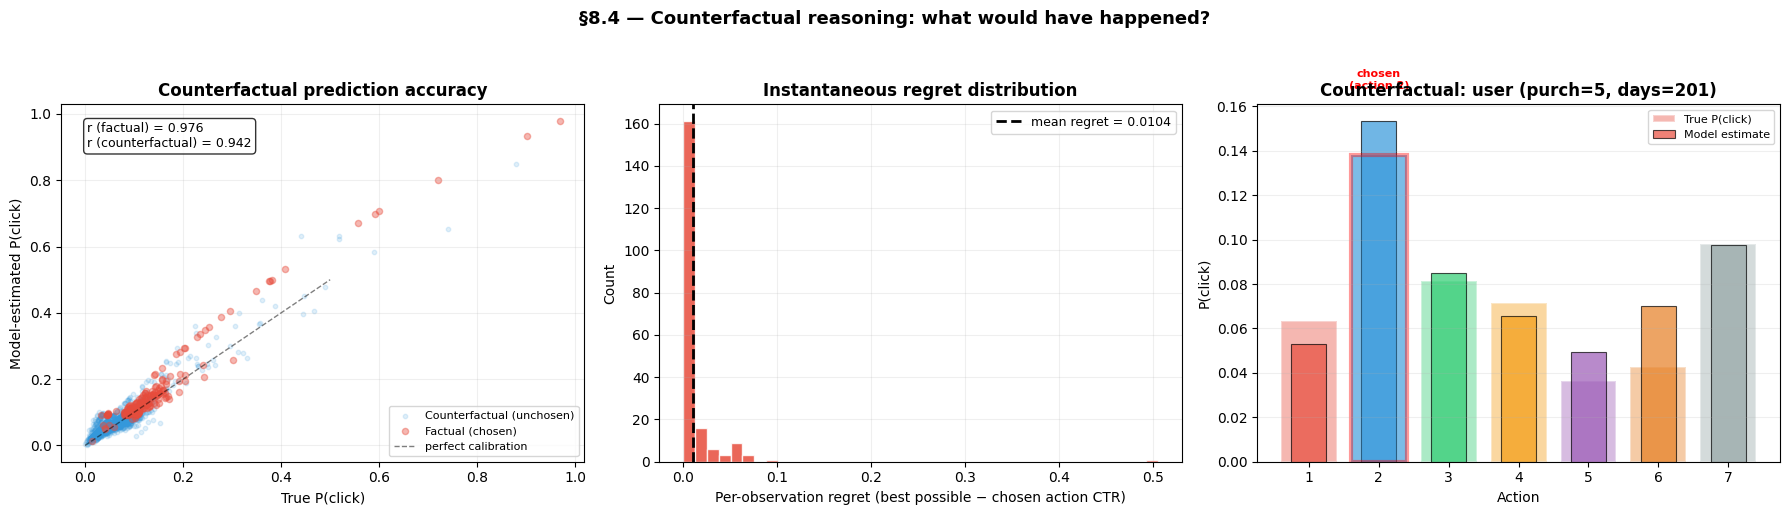

Model chose the oracle-optimal action 68.5% of the time
Average instantaneous regret: 0.0104
Median instantaneous regret:  0.0000
Zero-regret observations:     68.5%


In [18]:
# Counterfactual analysis: what if we'd chosen a different action?

# Collect a batch of interactions with full logging.
model_cf = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)
env_cf = BanditEnv(seed=42)
for t in range(10_000):
    x, _ = env_cf.sample_context()
    action, prop = model_cf.sample_action(x, 0.3, env_cf.rng)
    click = env_cf.sample_click(x, action)
    model_cf.update(x, action, click, prop, method='direct')

# Now log 200 interactions for counterfactual analysis.
N_CF = 200
cf_data = []
env_cf_log = BanditEnv(seed=777)
for i in range(N_CF):
    x, raw = env_cf_log.sample_context()
    action, prop = model_cf.sample_action(x, 0.1, env_cf_log.rng)
    click = env_cf_log.sample_click(x, action)
    cf_data.append({
        'x': x.copy(),
        'raw': raw,
        'action': action,
        'click': click,
        'prop': prop,
        'model_probs': model_cf.predict_proba(x).copy(),
        'true_probs': np.array([env_cf_log.click_prob(x, a) for a in range(1, K+1)]),
    })

# For each observation, estimate counterfactual CTR under all actions.
# Model-based: just use predict_proba.
# Compare to ground truth.
model_cf_errors = []
for obs in cf_data:
    for a in range(K):
        model_est = obs['model_probs'][a]
        true_prob = obs['true_probs'][a]
        model_cf_errors.append({
            'model_est': model_est,
            'true_prob': true_prob,
            'is_factual': (a + 1 == obs['action']),
        })

model_cf_errors = {k: np.array([e[k] for e in model_cf_errors]) for k in ['model_est', 'true_prob', 'is_factual']}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Model-estimated vs. true counterfactual probabilities.
ax = axes[0]
factual_mask = model_cf_errors['is_factual']
ax.scatter(model_cf_errors['true_prob'][~factual_mask],
           model_cf_errors['model_est'][~factual_mask],
           alpha=0.15, s=10, color='#3498db', label='Counterfactual (unchosen)')
ax.scatter(model_cf_errors['true_prob'][factual_mask],
           model_cf_errors['model_est'][factual_mask],
           alpha=0.4, s=20, color='#e74c3c', label='Factual (chosen)')
ax.plot([0, 0.5], [0, 0.5], 'k--', lw=1, alpha=0.5, label='perfect calibration')
ax.set_xlabel('True P(click)')
ax.set_ylabel('Model-estimated P(click)')
ax.set_title('Counterfactual prediction accuracy', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

r_factual = np.corrcoef(model_cf_errors['true_prob'][factual_mask],
                         model_cf_errors['model_est'][factual_mask])[0, 1]
r_counter = np.corrcoef(model_cf_errors['true_prob'][~factual_mask],
                         model_cf_errors['model_est'][~factual_mask])[0, 1]
ax.text(0.05, 0.95, f'r (factual) = {r_factual:.3f}\nr (counterfactual) = {r_counter:.3f}',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Regret distribution — how much CTR we left on the table.
ax = axes[1]
regrets = []
for obs in cf_data:
    best_true = np.max(obs['true_probs'])
    chosen_true = obs['true_probs'][obs['action'] - 1]
    regrets.append(best_true - chosen_true)
regrets = np.array(regrets)

ax.hist(regrets, bins=40, color='#e74c3c', alpha=0.85, edgecolor='white')
ax.axvline(np.mean(regrets), color='black', ls='--', lw=2,
           label=f'mean regret = {np.mean(regrets):.4f}')
ax.set_xlabel('Per-observation regret (best possible − chosen action CTR)')
ax.set_ylabel('Count')
ax.set_title('Instantaneous regret distribution', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Plot 3: Counterfactual "what if" for a single user.
ax = axes[2]
example = cf_data[0]
x_pos = np.arange(K)
bar_colors = [ACTION_COLORS[a] for a in range(K)]
chosen_idx = example['action'] - 1

ax.bar(x_pos, example['true_probs'], alpha=0.4, color=bar_colors,
       edgecolor='white', lw=1.5, label='True P(click)')
ax.bar(x_pos, example['model_probs'], alpha=0.7, color=bar_colors,
       edgecolor='black', lw=0.8, width=0.5, label='Model estimate')

ax.bar(chosen_idx, example['true_probs'][chosen_idx], alpha=0.4,
       color=bar_colors[chosen_idx], edgecolor='red', lw=3)

oracle_a = np.argmax(example['true_probs'])
ax.annotate(f'chosen\n(action {chosen_idx+1})',
            xy=(chosen_idx, example['true_probs'][chosen_idx]),
            xytext=(chosen_idx, example['true_probs'][chosen_idx] + 0.03),
            ha='center', fontsize=8, color='red', fontweight='bold')

if oracle_a != chosen_idx:
    missed_lift = example['true_probs'][oracle_a] - example['true_probs'][chosen_idx]
    ax.annotate(f'best (action {oracle_a+1})\nlift = +{missed_lift:.3f}',
                xy=(oracle_a, example['true_probs'][oracle_a]),
                xytext=(oracle_a, example['true_probs'][oracle_a] + 0.03),
                ha='center', fontsize=8, color='#27ae60', fontweight='bold')

action_labels = [f"{a+1}" for a in range(K)]
ax.set_xticks(x_pos)
ax.set_xticklabels(action_labels)
ax.set_xlabel('Action')
ax.set_ylabel('P(click)')
ax.set_title(f'Counterfactual: user (purch={example["raw"]["lifetime_purchases"]}, '
             f'days={example["raw"]["days_as_customer"]})',
             fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.2)

fig.suptitle('§8.4 — Counterfactual reasoning: what would have happened?',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary.
optimal_pct = np.mean([np.argmax(obs['true_probs']) + 1 == obs['action'] for obs in cf_data])
print(f"Model chose the oracle-optimal action {optimal_pct*100:.1f}% of the time")
print(f"Average instantaneous regret: {np.mean(regrets):.4f}")
print(f"Median instantaneous regret:  {np.median(regrets):.4f}")
print(f"Zero-regret observations:     {np.mean(regrets == 0)*100:.1f}%")

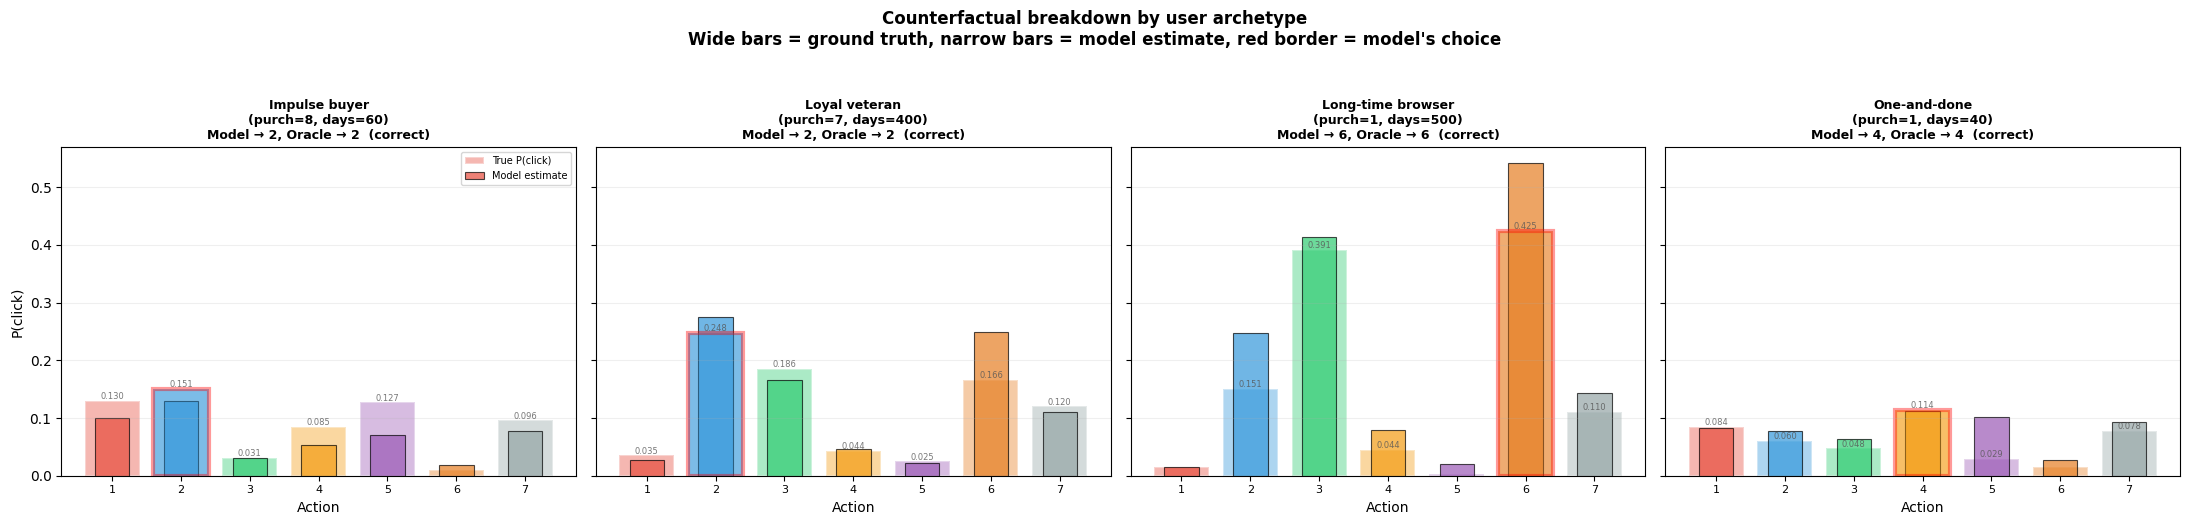

In [19]:
# Counterfactual "what if" for four representative user profiles.

profiles = [
    {"lifetime_purchases": 8, "days_as_customer": 60,  "label": "Impulse buyer"},
    {"lifetime_purchases": 7, "days_as_customer": 400, "label": "Loyal veteran"},
    {"lifetime_purchases": 1, "days_as_customer": 500, "label": "Long-time browser"},
    {"lifetime_purchases": 1, "days_as_customer": 40,  "label": "One-and-done"},
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for col, user in enumerate(profiles):
    ax = axes[col]
    ps = FEATURE_STATS["lifetime_purchases"]
    ds = FEATURE_STATS["days_as_customer"]
    x = np.array([1.0,
                  (user["lifetime_purchases"] - ps["mean"]) / ps["std"],
                  (user["days_as_customer"] - ds["mean"]) / ds["std"]])

    true_probs = np.array([env.click_prob(x, a) for a in range(1, K + 1)])
    model_probs = model_cf.predict_proba(x)
    model_choice = int(np.argmax(model_cf.W @ x))
    oracle_choice = int(np.argmax(true_probs))

    x_pos = np.arange(K)
    bar_colors = [ACTION_COLORS[a] for a in range(K)]

    ax.bar(x_pos, true_probs, alpha=0.4, color=bar_colors,
           edgecolor='white', lw=1.5, label='True P(click)')
    ax.bar(x_pos, model_probs, alpha=0.7, color=bar_colors,
           edgecolor='black', lw=0.8, width=0.5, label='Model estimate')

    ax.bar(model_choice, true_probs[model_choice], alpha=0.4,
           color=bar_colors[model_choice], edgecolor='red', lw=3)

    best_true = true_probs[oracle_choice]
    chosen_true = true_probs[model_choice]
    regret = best_true - chosen_true

    match_str = "correct" if model_choice == oracle_choice else f"regret = {regret:.3f}"
    ax.set_title(f'{user["label"]}\n(purch={user["lifetime_purchases"]}, '
                 f'days={user["days_as_customer"]})\n'
                 f'Model → {model_choice+1}, Oracle → {oracle_choice+1}  ({match_str})',
                 fontweight='bold', fontsize=9)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{a+1}" for a in range(K)], fontsize=8)
    ax.set_xlabel('Action')
    ax.grid(axis='y', alpha=0.2)

    if col == 0:
        ax.set_ylabel('P(click)')
        ax.legend(fontsize=7, loc='upper right')

    for a in range(K):
        if true_probs[a] > 0.02:
            ax.text(a, true_probs[a] + 0.003, f'{true_probs[a]:.3f}',
                    ha='center', fontsize=6, color='#555', alpha=0.8)

fig.suptitle('Counterfactual breakdown by user archetype\n'
             'Wide bars = ground truth, narrow bars = model estimate, '
             'red border = model\'s choice',
             fontweight='bold', fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

### 8.5 Meta-learner taxonomy — where bandits fit in causal ML

Our bandit model is one approach to estimating heterogeneous treatment effects. The causal ML literature has developed a rich taxonomy of **meta-learners** — algorithms that use standard supervised learning as a subroutine to estimate CATE. Understanding where bandits fit in this landscape is crucial for choosing the right tool in production.

#### T-learner (Two/Separate model learner)

**Idea:** Train a *separate* outcome model for each treatment group.

$$\hat{\mu}_a(x) = \text{Model}_a\bigl(\text{data where } A = a\bigr), \quad \hat{\tau}(x; a, a') = \hat{\mu}_a(x) - \hat{\mu}_{a'}(x)$$

**Our bandit IS a T-learner.** Each action's weight vector $w_a$ is a separate model trained only on observations where that action was chosen. The CATE is the difference in predictions.

| Pros | Cons |
|------|------|
| Simple, flexible — any ML model works | Doesn't share information across actions |
| Natural for bandits (per-action models) | Inefficient when some actions have little data |
| No assumptions about treatment effect structure | CATE is a *difference* of two noisy estimates → high variance |

#### S-learner (Single model learner)

**Idea:** Train *one* model on all data, including the action as a feature.

$$\hat{\mu}(x, a) = \text{Model}\bigl(\text{all data, with } a \text{ as input}\bigr), \quad \hat{\tau}(x; a, a') = \hat{\mu}(x, a) - \hat{\mu}(x, a')$$

The model must learn that $a$ matters — it discovers treatment heterogeneity through interactions between $x$ and $a$.

| Pros | Cons |
|------|------|
| Shares data across all actions | Regularization can shrink treatment effects toward zero |
| More data-efficient when effects are small | Model must learn x–a interactions (harder for trees/linear models) |
| Single model to maintain | Can miss small but real treatment effects |

**In our setting:** An S-learner would use a single weight matrix $W \in \mathbb{R}^{(d + K) \times 1}$, treating action indicators as features. This forces shared feature weights across actions, which hurts when actions have genuinely different feature responses.

#### X-learner (Cross learner) — Künzel et al., 2019

**Idea:** A two-stage procedure designed for **imbalanced treatment groups** (common in observational data).

**Stage 1 (like T-learner):** Fit separate models per action: $\hat{\mu}_0(x)$, $\hat{\mu}_1(x)$.

**Stage 2 (impute counterfactuals):** For treated units, impute what *would have happened* without treatment: $\tilde{D}_1 = Y_1 - \hat{\mu}_0(x)$. For control units: $\tilde{D}_0 = \hat{\mu}_1(x) - Y_0$. Then fit CATE models on each group's imputed effects.

**Stage 3 (combine):** Weight the two CATE estimates by the propensity score: $\hat{\tau}(x) = e(x) \cdot \hat{\tau}_0(x) + (1 - e(x)) \cdot \hat{\tau}_1(x)$.

| Pros | Cons |
|------|------|
| Excellent with imbalanced groups | More complex; three modeling stages |
| Uses propensity scores to handle confounding | Designed for binary treatment (extensions to multi-arm exist but are less standard) |
| Can outperform T/S-learner in small samples | Imputed pseudo-outcomes can be noisy |

#### R-learner (Robinson decomposition) — Nie & Wager, 2021

**Idea:** Directly optimize for CATE by *partialling out* the main effects of $X$ and $A$.

**Step 1:** Estimate nuisance functions:
- $\hat{m}(x) = E[Y \mid X = x]$ (outcome model ignoring treatment)
- $\hat{e}(x) = E[A \mid X = x]$ (propensity model)

**Step 2:** Solve a *modified loss* that isolates the treatment effect:

$$\hat{\tau} = \arg\min_\tau \; E\Bigl[\bigl(Y - \hat{m}(X) - \tau(X)(A - \hat{e}(X))\bigr)^2\Bigr]$$

This is a form of **doubly robust** estimation — consistent if either $\hat{m}$ or $\hat{e}$ is correct. The name "R-learner" comes from the **R**obinson (1988) decomposition.

| Pros | Cons |
|------|------|
| Directly targets CATE (not outcome prediction) | Requires estimating nuisance functions |
| Doubly robust — consistent under partial misspecification | More complex optimization |
| Strong theoretical guarantees (Neyman-orthogonality) | Primarily designed for binary/continuous treatments |

#### DR-learner (Doubly Robust learner) — Kennedy, 2023

**Idea:** Construct **doubly robust pseudo-outcomes** and then regress them on $X$.

$$\tilde{Y}_{\text{DR}} = \hat{\mu}_1(x) - \hat{\mu}_0(x) + \frac{A(Y - \hat{\mu}_1(x))}{e(x)} - \frac{(1-A)(Y - \hat{\mu}_0(x))}{1 - e(x)}$$

Then fit: $\hat{\tau}(x) = \text{Model}(\tilde{Y}_{\text{DR}} \sim X)$.

This is closely related to our DR bandit update! The pseudo-outcome $\tilde{Y}_{\text{DR}}$ is an unbiased estimate of $\tau(x)$ if either the outcome model or the propensity model is correct — exactly the "doubly robust" property we discussed in §6.

| Pros | Cons |
|------|------|
| Unbiased pseudo-outcomes → simple final regression | Pseudo-outcomes can have high variance |
| Connects directly to DR in bandit literature | Needs good estimates of both $\hat{\mu}$ and $e$ |
| Oracle-efficient under regularity conditions | Primarily binary treatment |

### How these relate to each other

```
                        ┌──────────────────────────┐
                        │  Heterogeneous Treatment  │
                        │    Effect Estimation       │
                        └────────────┬─────────────┘
                                     │
                 ┌───────────────────┼───────────────────┐
                 │                   │                    │
           ┌─────┴─────┐     ┌──────┴──────┐     ┌──────┴──────┐
           │  Outcome   │     │  Treatment  │     │   Direct    │
           │  modeling  │     │  effect     │     │   CATE      │
           │            │     │  transform  │     │   targeting │
           └─────┬─────┘     └──────┬──────┘     └──────┬──────┘
                 │                   │                    │
          ┌──────┼──────┐     ┌──────┼──────┐            │
          │      │      │     │      │      │            │
        T-lnr  S-lnr  X-lnr  DR-lnr  IPW    │       R-learner
          │                                   │
          │                                   │
     ┌────┴────────────────────────────────────┘
     │
  Our bandit = T-learner + online SGD + ε-greedy exploration
```

### Key takeaway

The bandit framework gives us something the batch causal ML approaches don't: **adaptive data collection**. A T-learner trained on observational data can only estimate CATE from whatever treatment assignments happened to occur. A bandit actively *explores* to fill in gaps in its CATE estimates — it's both the estimator and the experimenter.

Conversely, the causal ML literature gives us tools the basic bandit doesn't have:
- **Doubly robust estimation** for handling confounding in logged data (we saw this in §6)
- **Cross-fitting** and **Neyman-orthogonality** for valid inference on CATE
- **Sensitivity analysis** for assessing robustness to unobserved confounders

In production, you'd combine both: run a bandit for adaptive data collection, then use causal ML methods for rigorous post-hoc analysis of treatment effects.

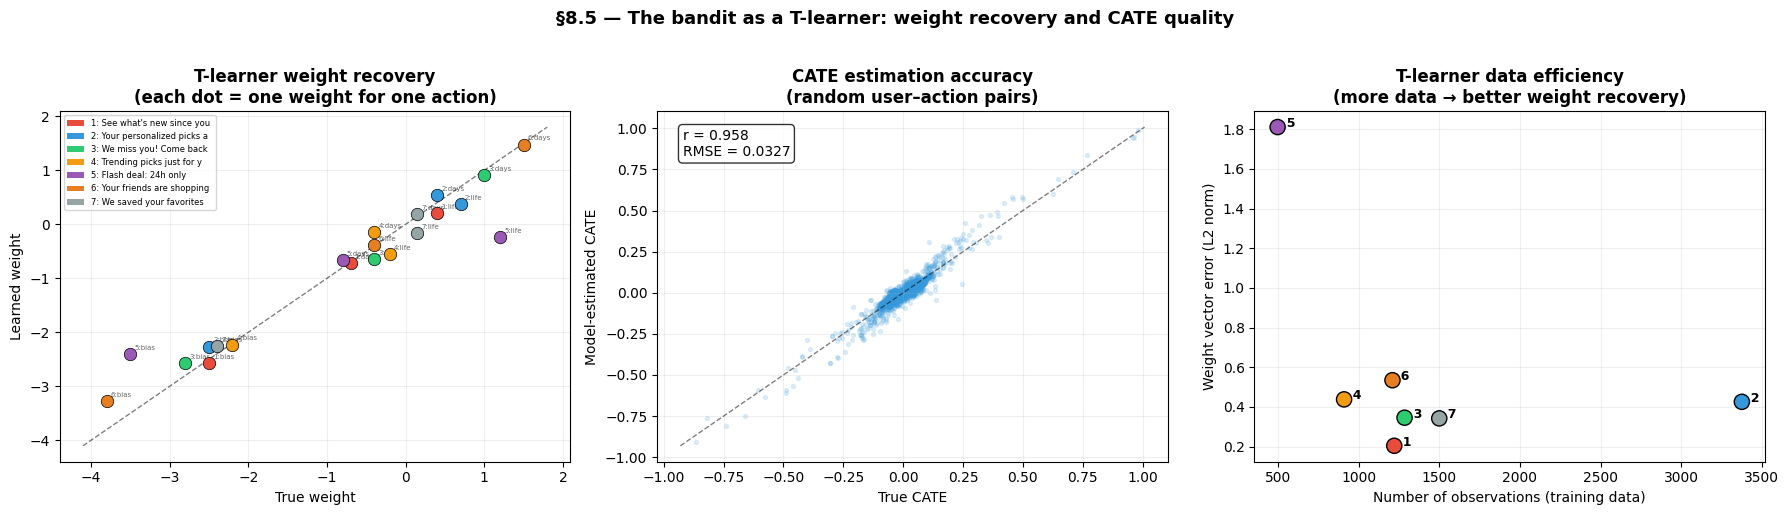

Per-action training observations and weight error:
  1: See what's new since you left        obs=  1221  L2 error=0.204
  2: Your personalized picks await        obs=  3376  L2 error=0.425
  3: We miss you! Come back               obs=  1285  L2 error=0.345
  4: Trending picks just for you          obs=   910  L2 error=0.438
  5: Flash deal: 24h only                 obs=   498  L2 error=1.811
  6: Your friends are shopping            obs=  1210  L2 error=0.534
  7: We saved your favorites              obs=  1500  L2 error=0.342


In [20]:
# Demonstrate the bandit-as-T-learner: compare per-action weight vectors
# to the ground truth, and show CATE estimation quality.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Learned weights vs. true weights (per action).
ax = axes[0]
for a in range(K):
    ax.scatter(W_TRUE[a], model_causal.W[a], color=ACTION_COLORS[a],
               s=80, zorder=5, edgecolor='black', lw=0.5)
    for f_idx in range(3):
        ax.annotate(f'{a+1}:{feature_labels[f_idx][:4]}',
                    (W_TRUE[a, f_idx], model_causal.W[a, f_idx]),
                    fontsize=5, alpha=0.6,
                    xytext=(3, 3), textcoords='offset points')

wmin = min(W_TRUE.min(), model_causal.W.min()) - 0.3
wmax = max(W_TRUE.max(), model_causal.W.max()) + 0.3
ax.plot([wmin, wmax], [wmin, wmax], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('True weight')
ax.set_ylabel('Learned weight')
ax.set_title('T-learner weight recovery\n(each dot = one weight for one action)', fontweight='bold')
ax.grid(alpha=0.2)

legend_elements = [Patch(facecolor=ACTION_COLORS[a], label=f'{a+1}: {ACTION_NAMES[a+1][:25]}')
                   for a in range(K)]
ax.legend(handles=legend_elements, fontsize=6, loc='upper left')

# Plot 2: CATE estimation accuracy — scatter of model vs oracle CATE
# for a random sample of users and action pairs.
ax = axes[1]
env_cate = BanditEnv(seed=555)
cate_model_vals, cate_true_vals = [], []
for _ in range(2000):
    x, _ = env_cate.sample_context()
    m_probs = model_causal.predict_proba(x)
    t_probs = np.array([env_cate.click_prob(x, a) for a in range(1, K+1)])
    a1, a2 = env_cate.rng.choice(K, size=2, replace=False)
    cate_model_vals.append(m_probs[a1] - m_probs[a2])
    cate_true_vals.append(t_probs[a1] - t_probs[a2])

cate_model_vals = np.array(cate_model_vals)
cate_true_vals = np.array(cate_true_vals)

ax.scatter(cate_true_vals, cate_model_vals, alpha=0.15, s=8, color='#3498db')
cmin = min(cate_true_vals.min(), cate_model_vals.min()) - 0.02
cmax = max(cate_true_vals.max(), cate_model_vals.max()) + 0.02
ax.plot([cmin, cmax], [cmin, cmax], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('True CATE')
ax.set_ylabel('Model-estimated CATE')
ax.set_title('CATE estimation accuracy\n(random user–action pairs)', fontweight='bold')
ax.grid(alpha=0.2)

r = np.corrcoef(cate_true_vals, cate_model_vals)[0, 1]
rmse = np.sqrt(np.mean((cate_model_vals - cate_true_vals)**2))
ax.text(0.05, 0.95, f'r = {r:.3f}\nRMSE = {rmse:.4f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 3: Per-action data efficiency — how many observations
# each action received during training, and its weight recovery.
ax = axes[2]
env_count = BanditEnv(seed=42)
model_count = LinearBanditModel(n_actions=K, n_features=3, lr=0.1)
action_obs_counts = np.zeros(K)
for t in range(10_000):
    x, _ = env_count.sample_context()
    action, prop = model_count.sample_action(x, 0.3, env_count.rng)
    click = env_count.sample_click(x, action)
    model_count.update(x, action, click, prop, method='direct')
    action_obs_counts[action - 1] += 1

weight_errors = np.array([np.linalg.norm(model_count.W[a] - W_TRUE[a])
                          for a in range(K)])

ax.scatter(action_obs_counts, weight_errors, color=ACTION_COLORS, s=120,
           edgecolor='black', lw=1, zorder=5)
for a in range(K):
    ax.annotate(f'  {a+1}', (action_obs_counts[a], weight_errors[a]),
                fontsize=9, fontweight='bold')
ax.set_xlabel('Number of observations (training data)')
ax.set_ylabel('Weight vector error (L2 norm)')
ax.set_title('T-learner data efficiency\n(more data → better weight recovery)', fontweight='bold')
ax.grid(alpha=0.2)

fig.suptitle('§8.5 — The bandit as a T-learner: weight recovery and CATE quality',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Per-action training observations and weight error:")
for a in range(K):
    print(f"  {a+1}: {ACTION_NAMES[a+1]:35s}  obs={action_obs_counts[a]:6.0f}  "
          f"L2 error={weight_errors[a]:.3f}")

### 8.6 Action-dependent features — from action IDs to action properties

So far, our model treats each action as an **opaque integer ID**. Action 5 is just "action 5" — the model learns a separate weight vector $w_5$ with no structural relationship to $w_1, w_2, \ldots$ In our toy setting this is fine (7 actions, simple features), but in production it's a major limitation.

#### The problem with action IDs

Consider a real re-engagement system with 50 message variants. A T-learner needs to learn 50 separate weight vectors — and most actions will have sparse training data (the long tail of the action distribution we saw in §3). Worse:

- **No generalization across actions.** If action 12 ("20% off your next order") works well for price-sensitive users, that tells the model nothing about action 37 ("25% off + free shipping"). The actions share no structure.
- **No zero-shot prediction.** If the marketing team creates a new variant tomorrow, the model has zero knowledge about it. It must explore from scratch.
- **Opaque explanations.** Explaining "we picked action 12" is meaningless to a stakeholder. What *about* action 12 made it the right choice?

#### The solution: action features

Instead of treating actions as IDs, describe each action with a **feature vector** $z_a$ that captures its properties:

| Action | ID-only | With action features |
|--------|---------|---------------------|
| "Flash deal: 24h only" | $a = 5$ | $z_5 = [\text{urgency}=0.9,\; \text{warmth}=0.1,\; \text{discount}=0.0,\; \text{social}=0.0]$ |
| "We miss you! Come back" | $a = 3$ | $z_3 = [\text{urgency}=0.1,\; \text{warmth}=0.9,\; \text{discount}=0.0,\; \text{social}=0.2]$ |
| "Your friends are shopping" | $a = 6$ | $z_6 = [\text{urgency}=0.2,\; \text{warmth}=0.3,\; \text{discount}=0.0,\; \text{social}=0.9]$ |

Now the model predicts CTR using **both** user features and action features:

$$\hat{p}(\text{click} \mid x, z_a) = \sigma\!\bigl(x^\top W z_a\bigr)$$

where $W \in \mathbb{R}^{d_x \times d_z}$ is a **single shared interaction matrix**. This is a bilinear model — it learns *which user properties interact with which action properties*.

#### Why this transforms explainability

**1. Explanations become meaningful.**

Instead of "we picked action 5", you can say:

> *"This user has high purchase history and short tenure (impulse buyer profile). The model learned that impulse buyers respond strongly to urgency cues. Action 5 scores highest because it has the highest urgency feature among all variants."*

The explanation decomposes into:
- **User side:** which user features are driving the decision
- **Action side:** which action properties the user is receptive to
- **Interaction:** the specific user–action affinity

**2. CATE becomes interpretable.**

With action IDs: $\hat{\tau}(x;\, 5, 3) = \hat{p}(x, 5) - \hat{p}(x, 3)$ — "action 5 is better than action 3 for this user." Why? No idea.

With action features: $\hat{\tau}(x;\, z_5, z_3) = \sigma(x^\top W z_5) - \sigma(x^\top W z_3)$ — the treatment effect decomposes along action-feature dimensions. You can identify that the lift comes specifically from the **urgency dimension**: $z_5[\text{urgency}] - z_3[\text{urgency}] = 0.8$, interacting with this user's high purchase feature.

**3. Generalization to new actions.**

Suppose the marketing team proposes a new variant: "Last chance: your cart expires tonight" with action features $z_{\text{new}} = [\text{urgency}=0.95,\; \text{warmth}=0.0,\; \text{discount}=0.0,\; \text{social}=0.0]$.

The bilinear model can immediately predict CTR for every user via $\sigma(x^\top W z_{\text{new}})$ — no exploration needed for the initial estimate. The model knows how users respond to urgency from past data on other urgent messages. This is **zero-shot action generalization**.

#### Model architectures with action features

Several architectures support action features, ranging from simple to complex:

**Bilinear model** (simplest):
$$\hat{p}(x, z_a) = \sigma(x^\top W z_a)$$
- $W$ is a shared interaction matrix
- Linear in both $x$ and $z$, but captures cross-interactions
- Equivalent to our T-learner if $z_a$ are one-hot action indicators

**Factored model** (low-rank):
$$\hat{p}(x, z_a) = \sigma\!\bigl((U x)^\top (V z_a)\bigr)$$
- $U \in \mathbb{R}^{k \times d_x}$, $V \in \mathbb{R}^{k \times d_z}$ project both sides into a shared $k$-dimensional "affinity space"
- This is essentially **collaborative filtering** applied to bandits — similar to how Netflix matches users and movies
- Scales well when $d_x$ and $d_z$ are large (the shared space $k$ acts as a bottleneck)

**Neural model** (most expressive):
$$\hat{p}(x, z_a) = \sigma\!\bigl(f_\theta([x;\, z_a])\bigr)$$
- Concatenate user and action features, pass through a neural network
- Can learn arbitrary nonlinear interactions
- Commonly used in production recommendation systems

#### Connection to our notebook

Our current per-action weight vectors are secretly the degenerate case of action features. If we set $z_a$ to be a one-hot vector (all zeros except position $a$), then:

$$x^\top W z_a = x^\top W e_a = x^\top w_a$$

which is exactly our T-learner. The columns of $W$ *are* the per-action weight vectors. So our model is a bilinear model with one-hot action features — the least informative action representation possible.

#### Where action features come from in practice

| Source | Examples |
|--------|----------|
| **Metadata** | Message length, number of emojis, presence of discount, CTA button text |
| **Embeddings** | Sentence embeddings of the message text (BERT, etc.) |
| **Manual tags** | Tone (urgent, warm, formal), category, target persona |
| **Learned** | Latent action embeddings trained end-to-end with the bandit |

The most powerful setup combines manual tags (for interpretability) with learned embeddings (for performance). The tags give you the human-readable explanations; the embeddings capture nuances that tags miss.

#### Key takeaway

Action features are the bridge between **bandit optimization** (pick the best action) and **causal understanding** (understand *why* an action works for a user). Without them, you have a black box that maps user IDs to action IDs. With them, you have a model that explains decisions in terms of meaningful properties — and can generalize to actions it has never seen.